# 한우 등급 예측 전 EDA

목표: `LAST_GRADE` 예측 모델을 만들기 전에 데이터 구조, 결측치, 등급 분포, 도체 특성, 기상, 농장, 폐사, 혈통 데이터를 탐색합니다.

큰 파일이 있으므로 기본 설정은 `hanwoo_train.csv`와 `hanwoo_lineage.csv`를 일부 샘플로 읽습니다. 전체 데이터를 보고 싶으면 아래 설정값을 바꾸면 됩니다.

In [1]:
#!pip install missingno

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import missingno as msno
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None
    print('seaborn이 없어서 matplotlib 위주로 시각화합니다.')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 파일 경로와 읽기 설정

In [3]:
BASE_DIR = Path(r'C:\Users\jeehe\Data-Mining\hanwoo')

paths = {
    'train': BASE_DIR / 'hanwoo_train.csv',
    'weather': BASE_DIR / 'hanwoo_weather.csv',
    'area': BASE_DIR / 'hanwoo_area.csv',
    'death': BASE_DIR / 'hanwoo_death.csv',
    'lineage': BASE_DIR / 'hanwoo_lineage.csv',
}

dict_paths = {
    'train': BASE_DIR / 'hanwoo_train_colums.csv',
    'weather': BASE_DIR / 'hanwoo_weather_colums.csv',
    'area': BASE_DIR / 'hanwoo_area_colums.csv',
    'death': BASE_DIR / 'hanwoo_death_colums.csv',
    'lineage': BASE_DIR  / 'hanwoo_lineage_colums.csv',
}

# 큰 파일을 빠르게 보기 위한 설정입니다.
# 전체 train을 읽고 싶으면 USE_TRAIN_SAMPLE = False로 변경하세요.
USE_TRAIN_SAMPLE = True
TRAIN_SAMPLE_ROWS = 200_000
LINEAGE_SAMPLE_ROWS = 200_000

for name, path in paths.items():
    print(name, '->', path, '| exists:', path.exists())

train -> C:\Users\jeehe\Data-Mining\hanwoo\hanwoo_train.csv | exists: True
weather -> C:\Users\jeehe\Data-Mining\hanwoo\hanwoo_weather.csv | exists: True
area -> C:\Users\jeehe\Data-Mining\hanwoo\hanwoo_area.csv | exists: True
death -> C:\Users\jeehe\Data-Mining\hanwoo\hanwoo_death.csv | exists: True
lineage -> C:\Users\jeehe\Data-Mining\hanwoo\hanwoo_lineage.csv | exists: True


## 2. 데이터 불러오기

In [4]:
train = pd.read_csv(paths['train'], nrows=TRAIN_SAMPLE_ROWS if USE_TRAIN_SAMPLE else None)
weather = pd.read_csv(paths['weather'])
area = pd.read_csv(paths['area'])
death = pd.read_csv(paths['death'])
lineage_sample = pd.read_csv(paths['lineage'], nrows=LINEAGE_SAMPLE_ROWS)

data = {
    'train': train,
    'weather': weather,
    'area': area,
    'death': death,
    'lineage_sample': lineage_sample,
}

for name, df in data.items():
    print(f'{name}: {df.shape}')

train: (200000, 23)
weather: (973248, 7)
area: (91896, 5)
death: (321389, 4)
lineage_sample: (200000, 8)


## 3. 컬럼정의서와 실제 데이터 컬럼 비교

In [5]:
for name in ['train', 'weather', 'area', 'death', 'lineage']:
    dict_df = pd.read_csv(dict_paths[name])
    data_cols = list(pd.read_csv(paths[name], nrows=0).columns)
    dict_cols = dict_df['column_name'].tolist()
    missing_in_dict = [col for col in data_cols if col not in dict_cols]
    extra_in_dict = [col for col in dict_cols if col not in data_cols]
    print('=' * 60)
    print(name)
    print('실제 데이터 컬럼 수:', len(data_cols))
    print('정의서 컬럼 수:', len(dict_cols))
    print('정의서에 없는 실제 컬럼:', missing_in_dict)
    print('실제 데이터에 없는 정의서 컬럼:', extra_in_dict)

train
실제 데이터 컬럼 수: 23
정의서 컬럼 수: 23
정의서에 없는 실제 컬럼: []
실제 데이터에 없는 정의서 컬럼: []
weather
실제 데이터 컬럼 수: 7
정의서 컬럼 수: 7
정의서에 없는 실제 컬럼: []
실제 데이터에 없는 정의서 컬럼: []
area
실제 데이터 컬럼 수: 5
정의서 컬럼 수: 5
정의서에 없는 실제 컬럼: []
실제 데이터에 없는 정의서 컬럼: []
death
실제 데이터 컬럼 수: 4
정의서 컬럼 수: 4
정의서에 없는 실제 컬럼: []
실제 데이터에 없는 정의서 컬럼: []
lineage
실제 데이터 컬럼 수: 8
정의서 컬럼 수: 8
정의서에 없는 실제 컬럼: []
실제 데이터에 없는 정의서 컬럼: []


## 4. 데이터 미리보기

In [6]:
display(train.head())
display(weather.head())
display(area.head())
display(death.head())
display(lineage_sample.head())

,sido,sigungu,eupmyeondong,stn,ABATT_DATE,JUDGE_DATE,JUDGE_SEX,WEIGHT,BACKFAT,REA,WINDEX,WGRADE,INSFAT,YUKSAK,FATSAK,TISSUE,GROWTH,COST_AMT,AGE,BIRTH_YMD,CATTLE_NO,FARM_UNIQUE_NO,LAST_GRADE
0,강원특별자치도,정선군,북평면,563,2023-01-01,2023-01-02,암,218,3.0,44.0,63.23,A,1.0,6.0,7.0,5.0,9.0,-99.0,76,20160915,mI4i8G0BJ8kWD6gdm77RmTzyuIx6N2ZMaZ7wFXx3xb4=,hqh4Qmh5g+ymbYtqjAeKeA==,3B
1,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,520,12.0,100.0,61.46,B,4.0,5.0,3.0,3.0,3.0,-99.0,32,20200504,tMgfi1p35taO9GH4XN4x0bfO8czy79B8V9NyczRuV+8=,N5qW6dZ91QWCMHg/1kPdlA==,1B
2,경상북도,영주시,이산면,837,2023-01-01,2023-01-02,거세,452,14.0,104.0,61.86,B,9.0,4.0,3.0,1.0,3.0,-99.0,29,20200803,mdsSD4/sB06U68LNT6P/GUwei2ISyIBZ+R04iLw2mX0=,5UbtU8TgV2yu3Y4/jxuNMQ==,1++B
3,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,454,12.0,95.0,61.83,B,9.0,5.0,3.0,1.0,3.0,-99.0,32,20200510,LZWd4YatUD851LyC/LFXuxPW7KEXTwVWQONOwqrkLPI=,N5qW6dZ91QWCMHg/1kPdlA==,1++B
4,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,462,10.0,78.0,61.24,B,4.0,5.0,3.0,3.0,3.0,-99.0,32,20200511,A4FF/dhr8vg7JeW/eqc3922pA69nEaLL/+uoAusZqyU=,N5qW6dZ91QWCMHg/1kPdlA==,1B


,stn,date,ta_max,rn_day,ta_min,rhm_avg,ws_davg
0,95,2020-01-01,0.7,0.0,-9.0,78.4,0.7
1,95,2020-01-02,2.1,0.0,-4.7,87.8,0.7
2,95,2020-01-03,3.3,0.0,-8.4,82.0,0.6
3,95,2020-01-04,5.2,0.0,-9.7,79.3,0.6
4,95,2020-01-05,5.3,0.0,-10.4,78.3,0.5


,FARM_UNIQUE_NO,C2023,C2024,C2025,AREA
0,X8bGdfHedF2o5xSAAERtEA==,23.0,26.0,25.0,220.00
1,N9t4B2mc+EZsH7wBLT8U4Q==,37.0,34.0,32.0,431.05
2,DeEu4RIkIUXq7NyTBwD8vg==,10.0,5.0,3.0,265.82
3,fgQkQJ+iyrFZDHsC9ih9mQ==,35.0,41.0,40.0,593.80
4,2mUAsXfTviEJtFBM7s31uw==,16.0,14.0,15.0,155.61


,FARM_UNIQUE_NO,BIRTH_YMD,DEAD_YMD,DEAD_REASON
0,WiJdwGdfb+CC7Jg0Pn/aLA==,20070621,20250107,-99
1,gj6CI5LHYXz7druWs1ZEUQ==,20060705,20250106,-99
2,We6zq4c9yoG5GKrt1CbrdA==,20080610,20250103,-99
3,s67fGrSPXhX1Bgp+JDW9Aw==,20050408,20250108,-99
4,3lGF4dGtWtydlceogBluUA==,20080425,20250109,-99


,CATTLE_NO,KPN_NO,FATHER_CATTLE_NO,MOTHER_ANIMAL_NO,F_GMOTHER_ANIMAL_NO,F_GFATHER_CATTLE_NO,M_GMOTHER_ANIMAL_NO,M_GFATHER_CATTLE_NO
0,yaSF9EHVPBIFeOdxL/st19so274mMHAbxmME5JhQ0Jk=,mgzxMpKRCOrwfHqsCHzP47qdLKwCfR8ULPzyRiJVOkM=,AMohGlr/7kUmTZcSjmBDCZP7fGvHMGm2uWw51JIprKc=,cMfffVbj3vfDem0QlY2ZOZphrIldXYc+f60y3Hvq9nI=,efoeB0IMVAIi87aCUIsPhGDfry4wx/cULq0c7MLKFA4=,SgXkbJ+3aQWEQl4EoT96zIyQAo5tEjvHfdMR2mvaVXw=,wV9qjXaPXOkYKpKj9nip78T5MB5AVUSkcK5tDT5O8e0=,Pd9ODUb0XUGA5X8xdQ5AdlNZk4cl7vCd/UfKUhXezYk=
1,iCeTx0O5z/M8GAcglblMDFVCzmvnkdPVRKTQtIN4ZFg=,mgzxMpKRCOrwfHqsCHzP47qdLKwCfR8ULPzyRiJVOkM=,AMohGlr/7kUmTZcSjmBDCZP7fGvHMGm2uWw51JIprKc=,0JDDs8FOPj0ZsxNi8H9ko/sBDa3eRTB9bq4nbuhtcpY=,efoeB0IMVAIi87aCUIsPhGDfry4wx/cULq0c7MLKFA4=,SgXkbJ+3aQWEQl4EoT96zIyQAo5tEjvHfdMR2mvaVXw=,SKOzaLpnj/ojtvXerWQzc1HSyU2kDhtQ42ShRDVA+/8=,Gt6xHYYq6gyhiQ2S6czPsYfvPNtj7D/O/Tw7yzi4e5w=
2,vI7joD/5v0T+wqvjC0d/36Sv5y+9NG18W+y2/YRVllg=,KDcckdOdPX/Uve2c5f7RNbAQrB27wyafOtzqX260DT4=,FXlabyH9KcP+VEzuDdo2xilVUs4PIl83AVIsv3AWiNc=,u6rUplX8Xi7ldmcYV1+AVtyCkMZLao7JzGOBuD1COMU=,Z7eNcRWyZHwpzEUJhPMNvbajt2EK/v1qGltu/05jQNw=,xJEKH2EwTkJaR/ajqNUgMSSlHOxsrEXijgN2Er6PBFo=,kluWj1LiM8I6nYWfDenO7q4tJySB2AVV8z9cMqweuXA=,kluWj1LiM8I6nYWfDenO7q4tJySB2AVV8z9cMqweuXA=
3,j0URLNNWbjl9ypDnsdULQAhvQ4roRAFjP0kGszyEXXw=,PBpDKzobFwTYitup5cJrqGpOK6iVZJvV6r42rmEbbZY=,A+eYuVUY8/QwN4+Ddgs7Tvko8TjAN7AtZv2+aZy0xIc=,fvUhHnLXiy3xTVKmqY62z+s5RlegNhPaR9ex1Gx0eN0=,+qwqADxeX1176gNXAgnIZjCeAdxDM1LrO3pn87MdVzA=,6LFovs6S310gxvJaixkryaO54hmEUBGq2C/pHCgq2No=,Ck6/PtPWiRKlWc9/jjgKjpepUIaUD2NlOlYzbbEzSOs=,Ju4e/qNWdk0qXYEO/m2Ypv7BGAwqhScFw+zq9k+mjKU=
4,kOnOAfd4lRrulCE9uv9ekwUcP/W9Hs41K1i5U0OLAfo=,+mx1i1sOZ7tc0lLUnrEQjGghLy+l5BH5XrTmY72A9Zc=,mAaX9QxFXASjT6u+keurKA90ZDThZfQ5xJzY6bv/6/8=,f7xH6ZSCkAVcPimjhYi5OqHYDXTX8GxNo+R7GeJYQ0s=,hyumffzX44tVUGJ22AnMUaD3t+jU7DWWPeGQzzrAQM8=,PJRSI2aIwE+wgp9nIHhFVxIm2gDfLdmeDbdUjDsn4GI=,FhYpc9/PEsQfoBSv2l3Ihz8r96yhBvEWup1GsUjhvXY=,H0hzRqFLWYoL0ncDgFrEGDeHw//E0XvfVXSi749m7Iw=


## 5. 결측치와 -99 확인

가이드라인에서 결측치는 `-99`로 표기된다고 했으므로, 일반 `-99`를 `NaN`으로 변환

In [7]:


def simple_missing_table(df):
    rows = []
    for col in df.columns:
        # 이제 -99가 NaN으로 바뀌었으므로 이 한 줄로 모두 체크됩니다.
        nan_count = df[col].isna().sum()
        
        rows.append({
            'column': col,
            'nan_count': nan_count,
            'missing_total': nan_count,
            'missing_ratio': nan_count / len(df)
        })
    return pd.DataFrame(rows).sort_values('missing_total', ascending=False)

# 1. 먼저 모든 데이터셋의 -99(문자형 -99 포함)를 NaN으로 일괄 변환합니다.
for name, df in data.items():
    # 1) 숫자형 -99 변환
    df.replace(-99, np.nan, inplace=True)
    
    # 2) 문자열 컬럼들을 하나씩 확인하며 공백 제거 후 '-99'를 NaN으로 변환
    for col in df.columns:
        if df[col].dtype == 'object': # df[col]은 단일 열(Series)이므로 dtype 사용이 맞습니다!
            df[col] = df[col].str.strip().replace('-99', np.nan)

# 2. 변환된 결과를 출력합니다.
for name, df in data.items():
    print('=' * 60)
    print(name, df.shape)
    # 결측치가 1개라도 있는 컬럼만 출력 (0개인 것도 보려면 .query() 부분 삭제)
    display(simple_missing_table(df).query('missing_total > 0'))

train (200000, 23)


,column,nan_count,missing_total,missing_ratio
17,COST_AMT,75434,75434,0.377170
15,TISSUE,601,601,0.003005
12,INSFAT,600,600,0.003000
10,WINDEX,598,598,0.002990
13,YUKSAK,597,597,0.002985
9,REA,585,585,0.002925
14,FATSAK,420,420,0.002100
8,BACKFAT,402,402,0.002010


weather (973248, 7)


,column,nan_count,missing_total,missing_ratio
5,rhm_avg,48155,48155,0.049479
3,rn_day,15993,15993,0.016433
6,ws_davg,13602,13602,0.013976
2,ta_max,12364,12364,0.012704
4,ta_min,12364,12364,0.012704


area (91896, 5)


,column,nan_count,missing_total,missing_ratio
4,AREA,29043,29043,0.316042
3,C2025,15613,15613,0.169899
2,C2024,10984,10984,0.119526
1,C2023,5196,5196,0.056542


death (321389, 4)


,column,nan_count,missing_total,missing_ratio
3,DEAD_REASON,234276,234276,0.728948


lineage_sample (200000, 8)


,column,nan_count,missing_total,missing_ratio
1,KPN_NO,420,420,0.0021


### 전체 파일 기준 결측치 확인 옵션

`hanwoo_train.csv`, `hanwoo_lineage.csv`는 크기가 크므로 시간이 걸릴 수 있습니다. 전체 파일 기준으로 결측치를 세고 싶으면 `RUN_FULL_MISSING_CHECK = True`로 바꾸고 실행하세요.

In [8]:
RUN_FULL_MISSING_CHECK = False

def missing_by_chunks(path, chunksize=200_000):
    total_rows = 0
    nan_counts = None
    columns = None

    for chunk in pd.read_csv(path, chunksize=chunksize):
        if columns is None:
            columns = chunk.columns.tolist()
            nan_counts = pd.Series(0, index=columns, dtype='int64')

        total_rows += len(chunk)
        # 이제 -99가 모두 NaN이 되었으므로 isna() 하나로 전부 계산됩니다.
        nan_counts += chunk.isna().sum()

    result = pd.DataFrame({
        'column': columns,
        'total_rows': total_rows,
        'missing_total': nan_counts.values, # nan_count가 곧 총 결측치입니다.
    })
    
    result['missing_ratio'] = result['missing_total'] / result['total_rows']
    return result.sort_values('missing_total', ascending=False)

if RUN_FULL_MISSING_CHECK:
    full_missing_reports = {}
    for name, path in paths.items():
        print('checking:', name)
        full_missing_reports[name] = missing_by_chunks(path)
        # 결측치가 1개라도 있는 컬럼만 출력
        display(full_missing_reports[name].query('missing_total > 0'))

## 6. 날짜 변환과 기본 파생 변수

In [9]:
train['ABATT_DATE'] = pd.to_datetime(train['ABATT_DATE'], errors='coerce')
train['JUDGE_DATE'] = pd.to_datetime(train['JUDGE_DATE'], errors='coerce')
train['BIRTH_YMD'] = pd.to_datetime(train['BIRTH_YMD'].astype(str), format='%Y%m%d', errors='coerce')

weather['date'] = pd.to_datetime(weather['date'], errors='coerce')

death['BIRTH_YMD'] = pd.to_datetime(death['BIRTH_YMD'].astype(str), format='%Y%m%d', errors='coerce')
death['DEAD_YMD'] = pd.to_datetime(death['DEAD_YMD'].astype(str), format='%Y%m%d', errors='coerce')

train['abatt_year'] = train['ABATT_DATE'].dt.year
train['abatt_month'] = train['ABATT_DATE'].dt.month
train['judge_delay'] = (train['JUDGE_DATE'] - train['ABATT_DATE']).dt.days

season_map = {
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'fall', 10: 'fall', 11: 'fall'
}
train['abatt_season'] = train['abatt_month'].map(season_map)

weather['temp_gap'] = weather['ta_max'] - weather['ta_min']
weather['hot_day'] = (weather['ta_max'] >= 33).astype(int)
weather['cold_day'] = (weather['ta_min'] <= -10).astype(int)
weather['rain_day'] = (weather['rn_day'] > 0).astype(int)
weather['humid_day'] = (weather['rhm_avg'] >= 80).astype(int)

display(train[['ABATT_DATE', 'JUDGE_DATE', 'BIRTH_YMD', 'abatt_year', 'abatt_month', 'abatt_season']].head())
display(weather[['stn', 'date', 'ta_max', 'ta_min', 'temp_gap', 'hot_day', 'rain_day']].head())

,ABATT_DATE,JUDGE_DATE,BIRTH_YMD,abatt_year,abatt_month,abatt_season
0,2023-01-01,2023-01-02,2016-09-15,2023,1,winter
1,2023-01-01,2023-01-02,2020-05-04,2023,1,winter
2,2023-01-01,2023-01-02,2020-08-03,2023,1,winter
3,2023-01-01,2023-01-02,2020-05-10,2023,1,winter
4,2023-01-01,2023-01-02,2020-05-11,2023,1,winter


,stn,date,ta_max,ta_min,temp_gap,hot_day,rain_day
0,95,2020-01-01,0.7,-9.0,9.7,0,0
1,95,2020-01-02,2.1,-4.7,6.8,0,0
2,95,2020-01-03,3.3,-8.4,11.7,0,0
3,95,2020-01-04,5.2,-9.7,14.9,0,0
4,95,2020-01-05,5.3,-10.4,15.7,0,0


## 7. 타깃 변수 `LAST_GRADE` 분포

,count
LAST_GRADE,
1+B,25772
1++B,25351
1B,25288
2B,17447
1++A,14870
1+A,12323
1A,12296
1++C,11747
1+C,11725


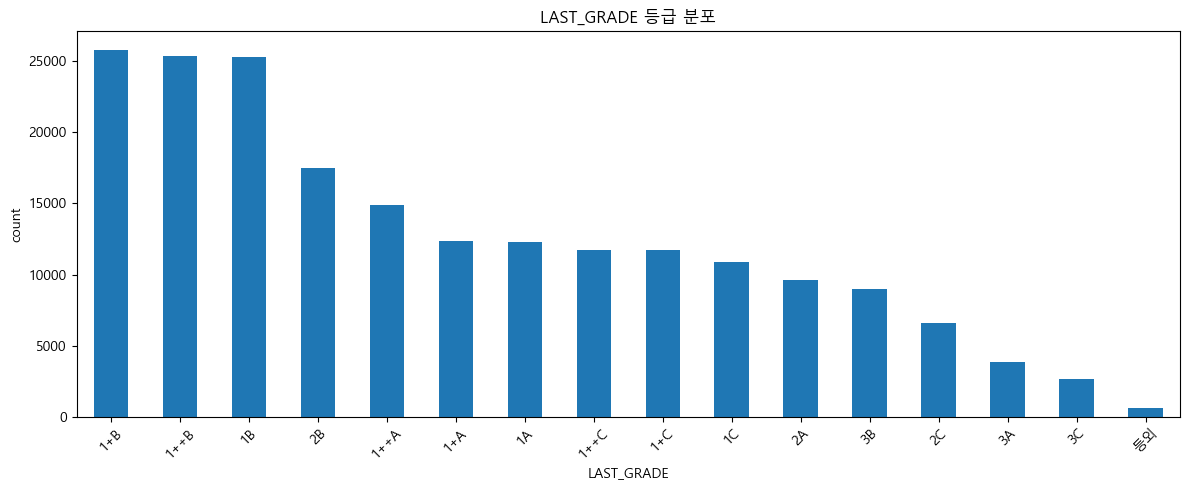

In [10]:
grade_counts = train['LAST_GRADE'].value_counts(dropna=False)
display(grade_counts.to_frame('count'))

plt.figure(figsize=(12, 5))
grade_counts.plot(kind='bar')
plt.title('LAST_GRADE 등급 분포')
plt.xlabel('LAST_GRADE')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. 도체 등급 판정 데이터 EDA

In [11]:
numeric_cols = [
    'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT',
    'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT', 'AGE', 'judge_delay'
]
numeric_cols = [col for col in numeric_cols if col in train.columns]

cat_cols = ['sido', 'sigungu', 'eupmyeondong', 'JUDGE_SEX', 'WGRADE', 'abatt_season']
cat_cols = [col for col in cat_cols if col in train.columns]

display(train[numeric_cols].describe().T)

for col in cat_cols:
    print('=' * 60)
    print(col)
    display(train[col].value_counts(dropna=False).head(20).to_frame('count'))

,count,mean,std,min,25%,50%,75%,max
WEIGHT,200000.0,419.464480,78.053119,48.00,366.00,420.00,474.0,782.00
BACKFAT,199598.0,13.233209,5.664889,1.00,10.00,13.00,16.0,90.00
REA,199415.0,92.894060,14.668686,2.00,84.00,93.00,102.0,187.00
WINDEX,199402.0,61.380757,1.879522,29.19,60.27,61.46,62.5,77.32
INSFAT,199400.0,5.364609,2.206330,1.00,4.00,6.00,7.0,9.00
YUKSAK,199403.0,4.974940,0.508845,1.00,5.00,5.00,5.0,8.00
FATSAK,199580.0,3.102846,0.440378,1.00,3.00,3.00,3.0,8.00
TISSUE,199399.0,2.187408,1.062259,1.00,1.00,2.00,3.0,5.00
GROWTH,200000.0,4.264015,2.289716,1.00,3.00,3.00,6.0,9.00
COST_AMT,124566.0,15458.983013,4729.685610,160.00,11990.00,16333.00,18491.0,49300.00


sido


,count
sido,
경상북도,49967
전라남도,34228
충청남도,24820
전북특별자치도,24436
경기도,17680
경상남도,16903
강원특별자치도,12523
충청북도,11354
울산광역시,1750


sigungu


,count
sigungu,
안동시,6237
정읍시,5979
상주시,5816
안성시,5544
장흥군,4790
영주시,4406
영암군,4003
구미시,3721
경주시,3697


...

,count
JUDGE_SEX,
거세,101117
암,97573
수,1310


WGRADE


,count
WGRADE,
B,96716
A,59645
C,43041
-99.0,548
D,50


abatt_season


,count
abatt_season,
winter,131247
spring,68753


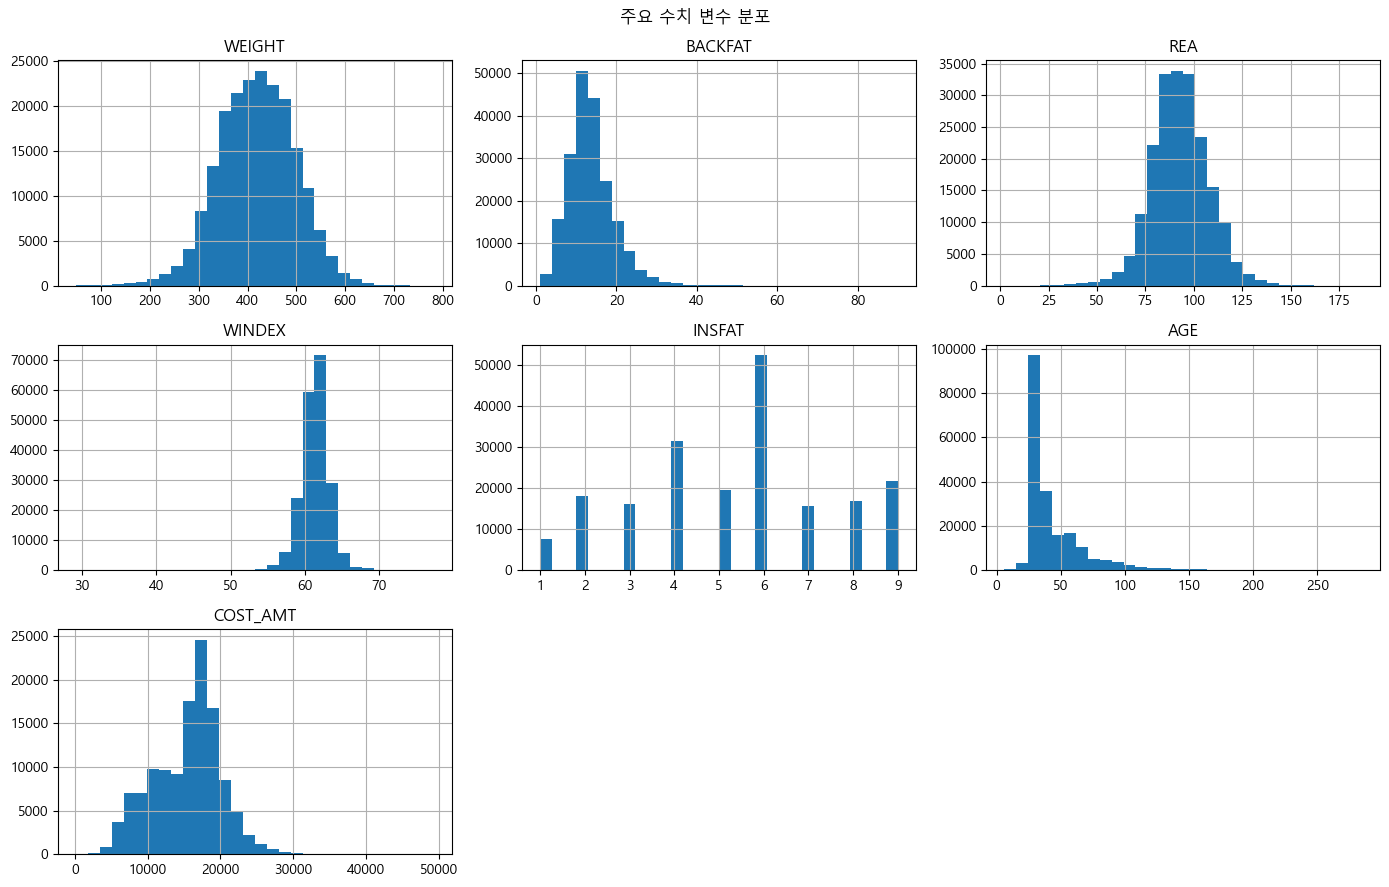

In [12]:
plot_cols = ['WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'AGE', 'COST_AMT']
plot_cols = [col for col in plot_cols if col in train.columns]

train[plot_cols].hist(figsize=(14, 9), bins=30)
plt.suptitle('주요 수치 변수 분포')
plt.tight_layout()
plt.show()

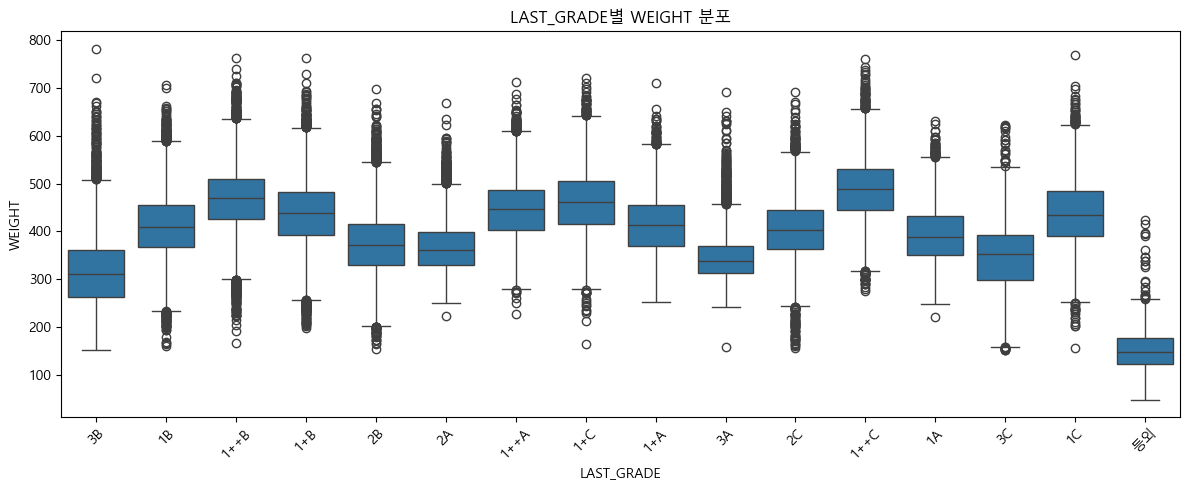

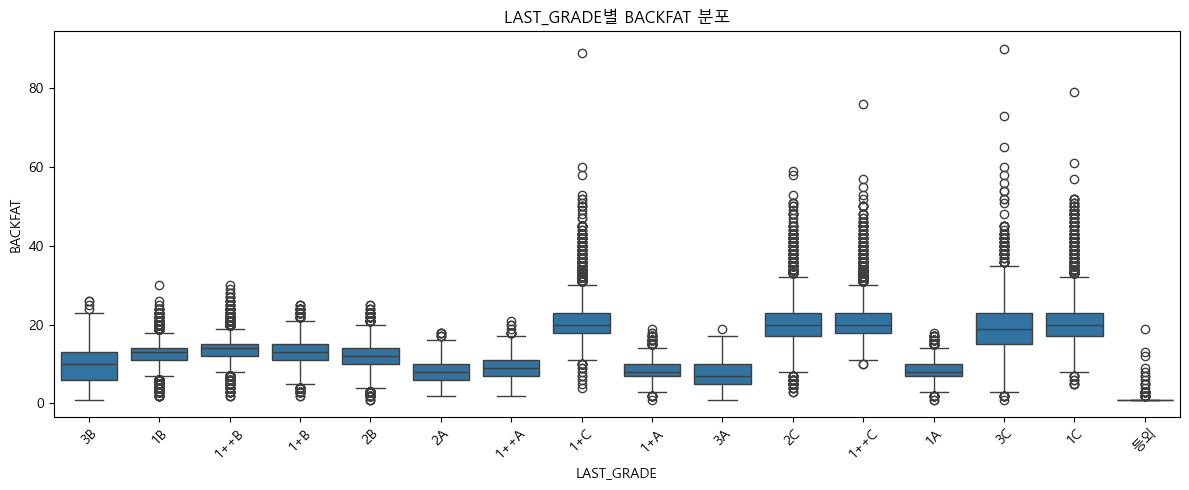

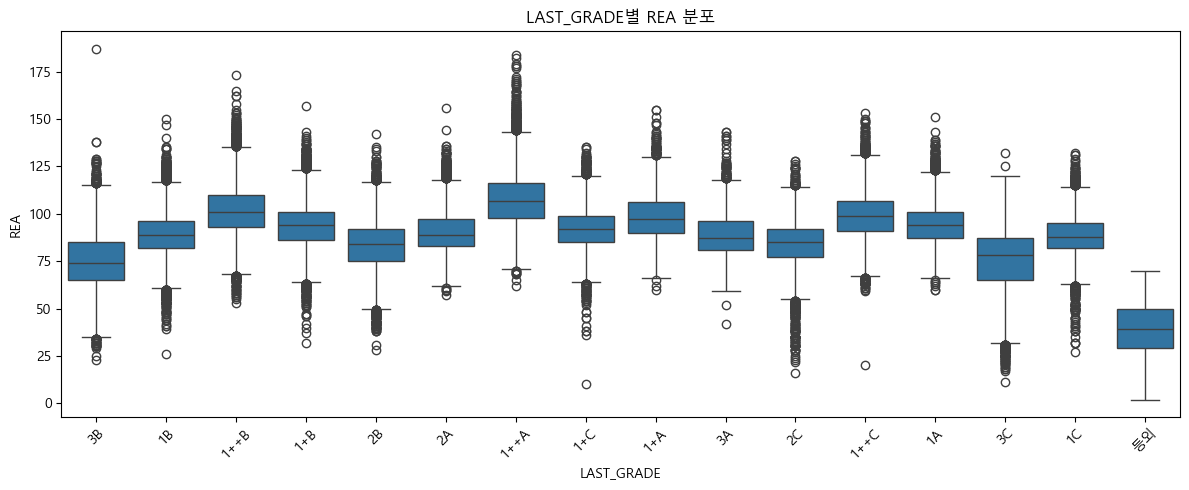

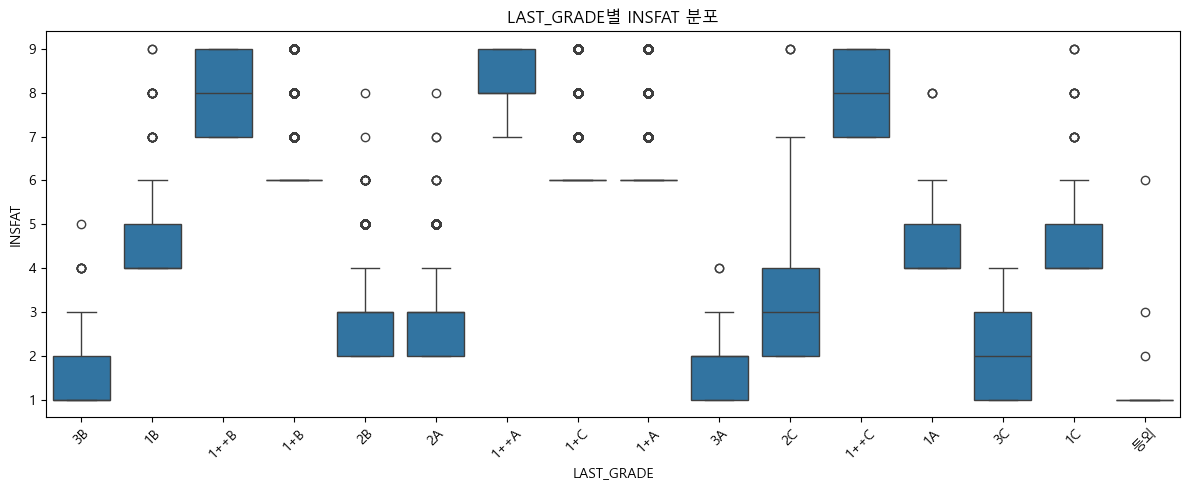

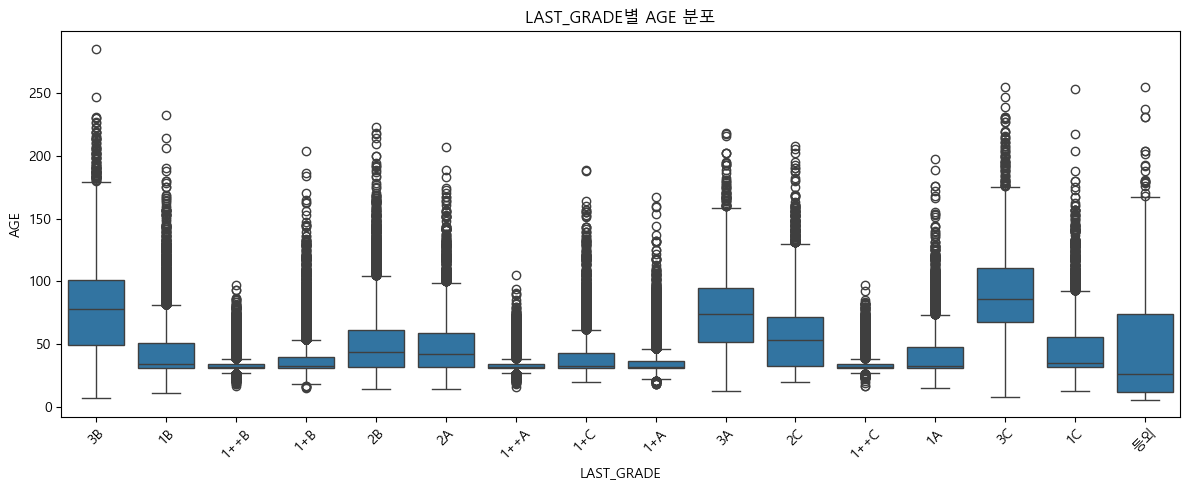

In [13]:
box_cols = ['WEIGHT', 'BACKFAT', 'REA', 'INSFAT', 'AGE']
box_cols = [col for col in box_cols if col in train.columns]

for col in box_cols:
    plt.figure(figsize=(12, 5))
    if sns is not None:
        sns.boxplot(data=train, x='LAST_GRADE', y=col)
    else:
        train.boxplot(column=col, by='LAST_GRADE', rot=45)
    plt.title(f'LAST_GRADE별 {col} 분포')
    plt.xlabel('LAST_GRADE')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

LAST_GRADE,1++A,1++B,1++C,1+A,1+B,1+C,1A,1B,1C,2A,2B,2C,3A,3B,3C,등외
abatt_month,,,,,,,,,,,,,,,,
1,0.077971,0.132257,0.061837,0.062591,0.131397,0.059906,0.058809,0.123225,0.055569,0.045003,0.083340,0.032863,0.018078,0.041670,0.012748,0.002737
2,0.069442,0.126912,0.058279,0.061281,0.128926,0.059753,0.061910,0.131101,0.054450,0.048033,0.087221,0.032142,0.018030,0.045893,0.013177,0.003451
3,0.074693,0.121422,0.055734,0.060976,0.126278,0.056313,0.063967,0.125683,0.052615,0.051457,0.090484,0.034315,0.021306,0.047758,0.013588,0.003409
4,0.070982,0.112567,0.055293,0.059254,0.123534,0.056207,0.065042,0.131150,0.053161,0.049962,0.101447,0.033816,0.023305,0.047068,0.015537,0.001676


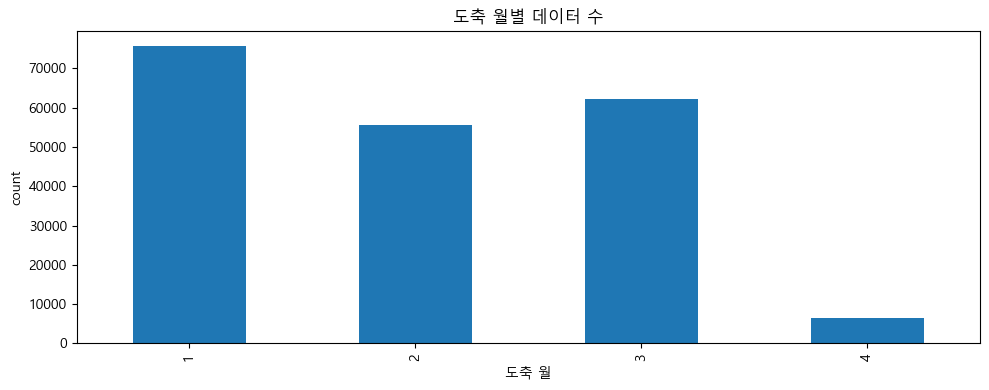

In [14]:
month_grade = pd.crosstab(train['abatt_month'], train['LAST_GRADE'], normalize='index')
display(month_grade)

month_count = train.groupby('abatt_month').size()
plt.figure(figsize=(10, 4))
month_count.plot(kind='bar')
plt.title('도축 월별 데이터 수')
plt.xlabel('도축 월')
plt.ylabel('count')
plt.tight_layout()
plt.show()

## 9. 기상 데이터 EDA

기상 날짜 범위: 2020-01-01 00:00:00 ~ 2025-12-31 00:00:00
관측소 수: 444


,count,mean,std,min,25%,50%,75%,max
ta_max,960884.0,19.005113,9.775284,-15.2,11.1,20.2,27.1,43.4
ta_min,960884.0,8.345552,10.616038,-28.2,-0.3,8.3,17.9,33.3
rn_day,957255.0,3.821074,13.984352,0.0,0.0,0.0,0.5,438.9
rhm_avg,925093.0,72.238375,15.100349,11.0,62.3,74.6,83.8,100.0
ws_davg,959646.0,1.814154,1.202354,0.1,1.0,1.5,2.2,22.3
temp_gap,960884.0,10.659561,4.431232,0.0,7.4,10.4,13.6,41.1


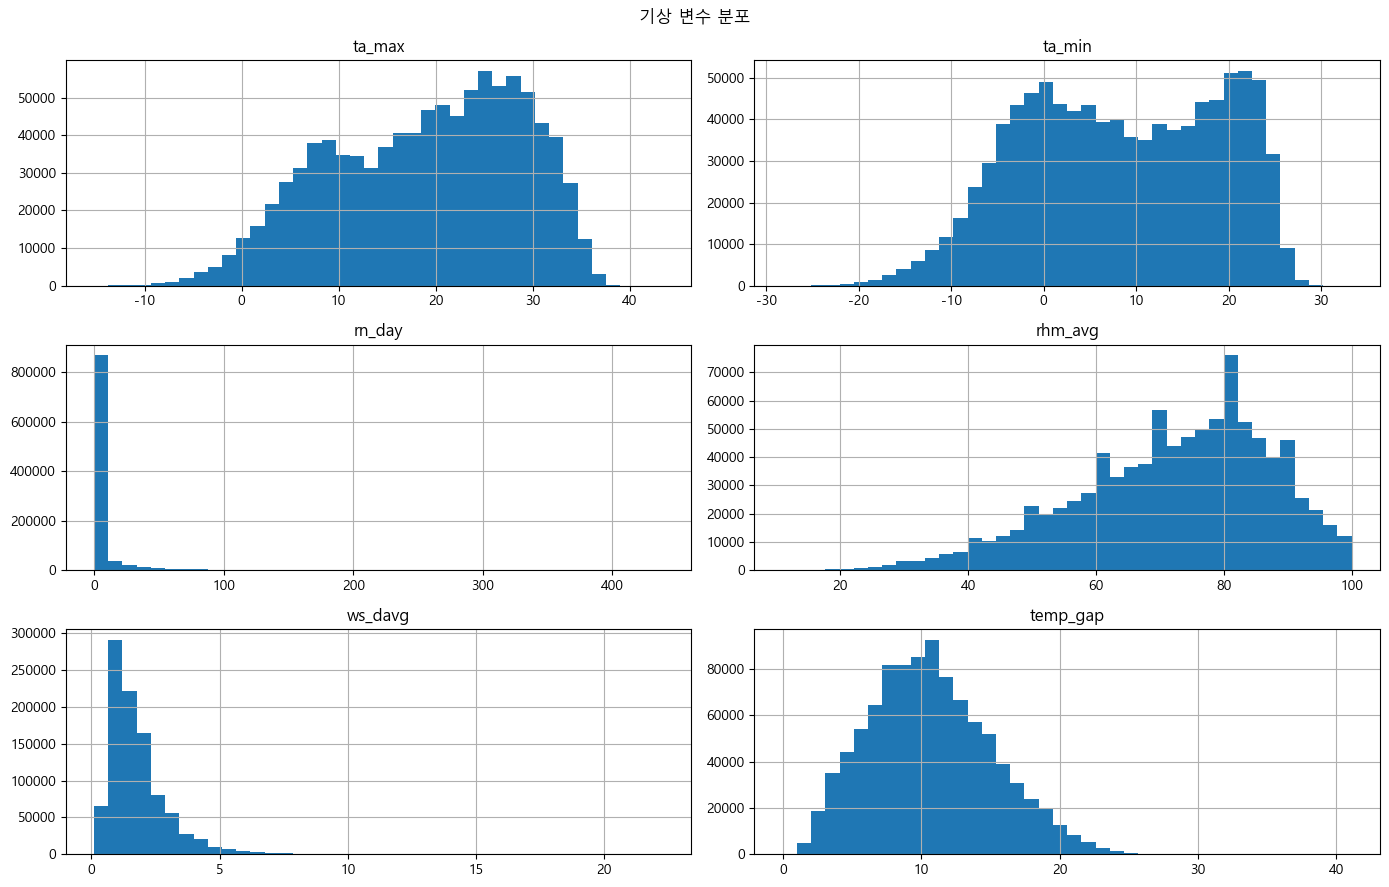

In [15]:
print('기상 날짜 범위:', weather['date'].min(), '~', weather['date'].max())
print('관측소 수:', weather['stn'].nunique())

weather_num_cols = ['ta_max', 'ta_min', 'rn_day', 'rhm_avg', 'ws_davg', 'temp_gap']
display(weather[weather_num_cols].describe().T)

weather[weather_num_cols].hist(figsize=(14, 9), bins=40)
plt.suptitle('기상 변수 분포')
plt.tight_layout()
plt.show()

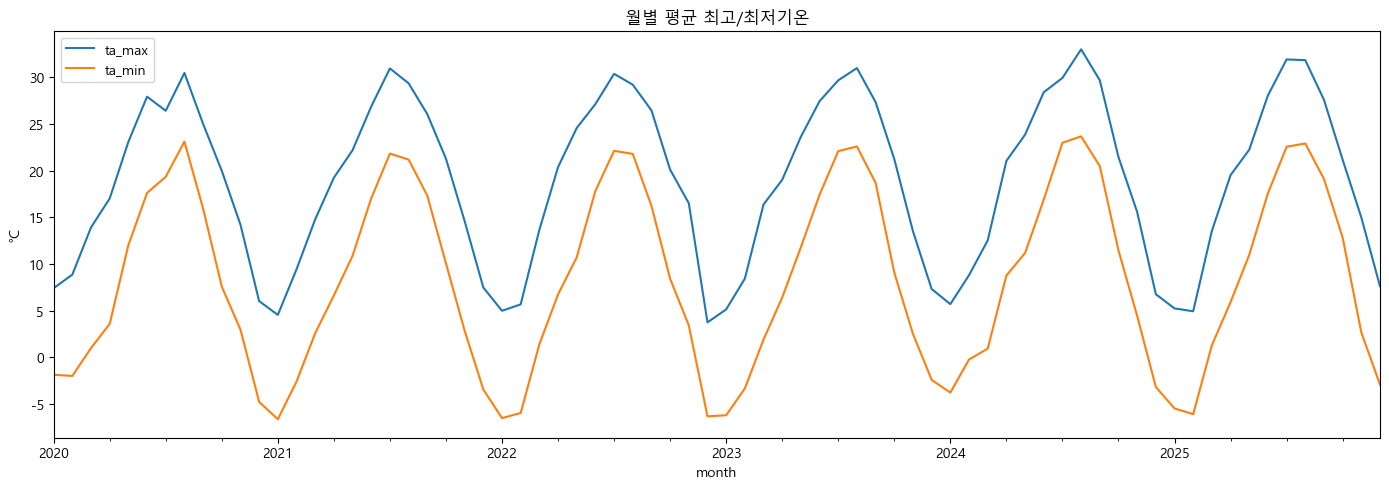

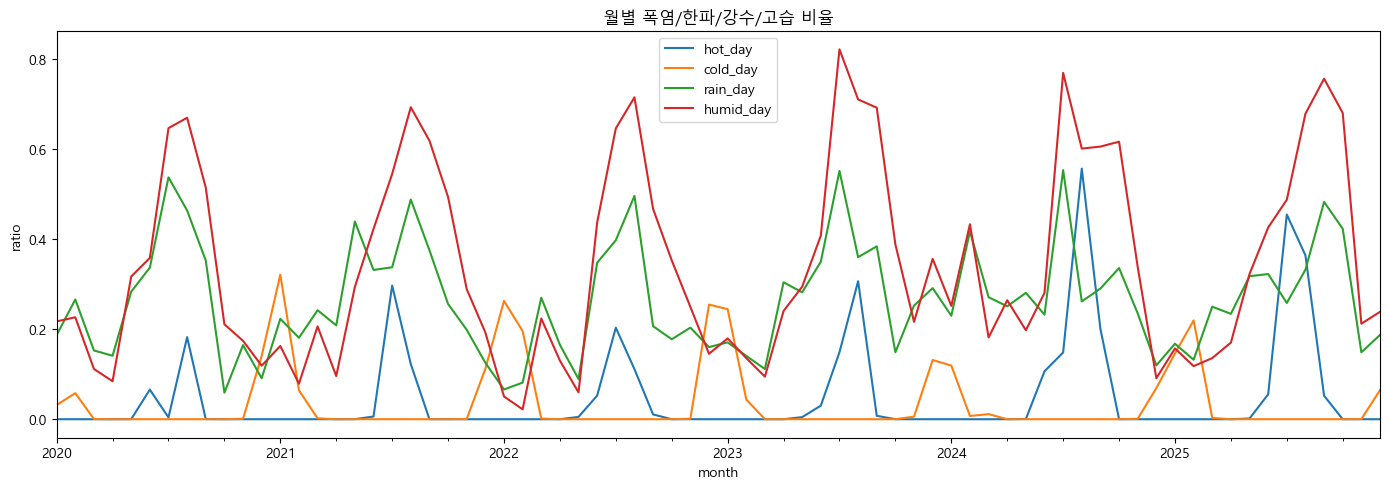

In [16]:
weather_monthly = (
    weather
    .assign(month=weather['date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month')[['ta_max', 'ta_min', 'rhm_avg', 'rn_day', 'ws_davg', 'hot_day', 'cold_day', 'rain_day', 'humid_day']]
    .mean()
)

plt.figure(figsize=(14, 5))
weather_monthly[['ta_max', 'ta_min']].plot(ax=plt.gca())
plt.title('월별 평균 최고/최저기온')
plt.xlabel('month')
plt.ylabel('℃')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
weather_monthly[['hot_day', 'cold_day', 'rain_day', 'humid_day']].plot(ax=plt.gca())
plt.title('월별 폭염/한파/강수/고습 비율')
plt.xlabel('month')
plt.ylabel('ratio')
plt.tight_layout()
plt.show()

# 9.1 기상 결측치 확인

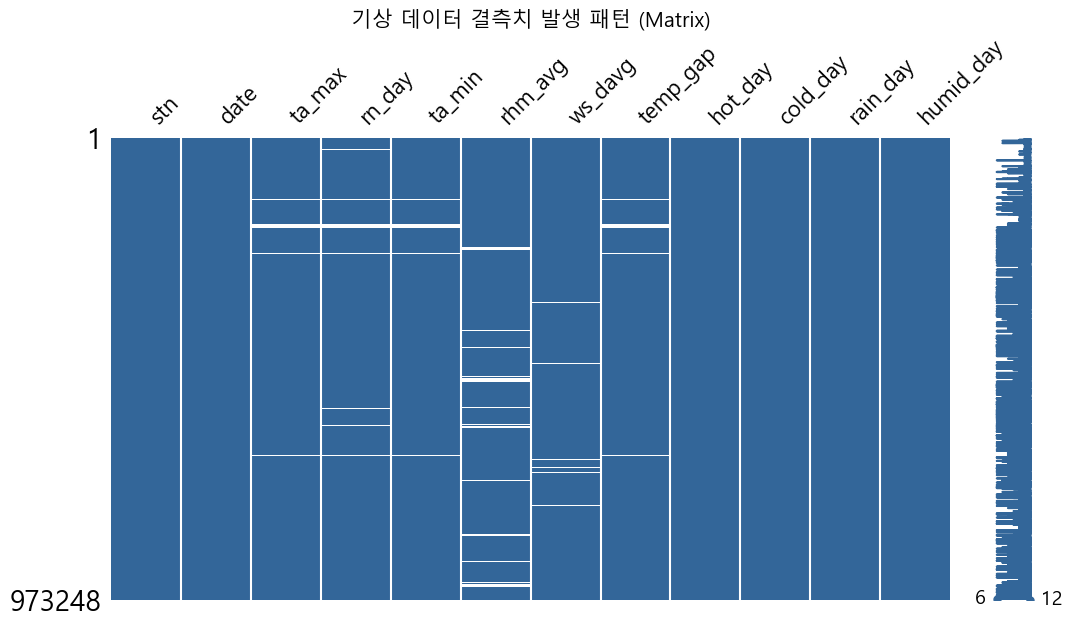

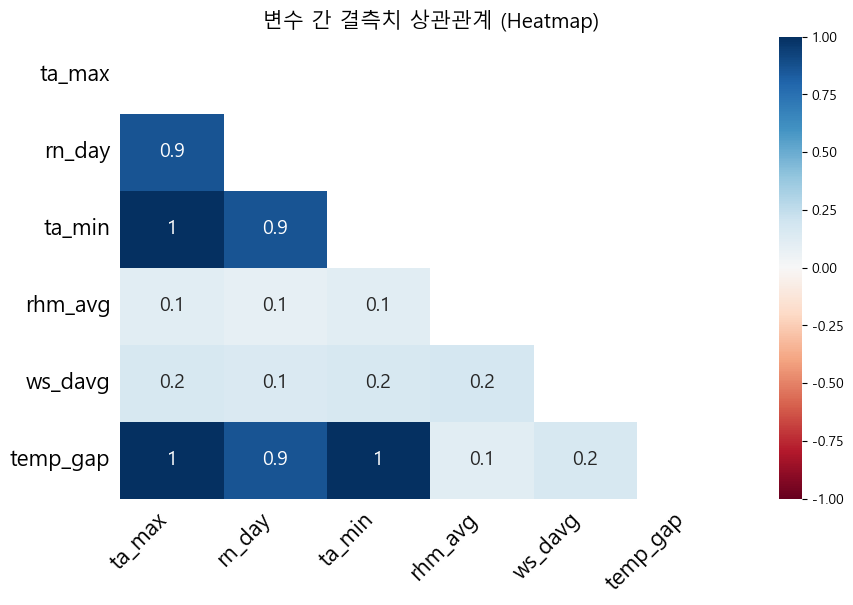

In [17]:
# 1. 결측치 발생 형태 시각화 (Matrix)
# 하얀색 실선이 얇게 흩뿌려져 있으면 -> '산발적 결측 (중간중간 빔)'
# 하얀색 띠가 두껍게 뭉쳐 있으면 -> '연속적 결측 (장기간 빔)'
msno.matrix(weather, figsize=(12, 6), color=(0.2, 0.4, 0.6))
plt.title('기상 데이터 결측치 발생 패턴 (Matrix)', fontsize=15)
plt.show()

# 2. 결측치 간의 상관관계 시각화 (Heatmap)
# 1에 가까울수록: "A가 비어있을 때 B도 무조건 비어있다!" (동시 결측)
# 0에 가까울수록: "둘의 결측 발생은 아무런 관계가 없다."
msno.heatmap(weather, figsize=(10, 6))
plt.title('변수 간 결측치 상관관계 (Heatmap)', fontsize=15)
plt.show()

In [18]:
# 관측장소 id 기준 병합해서 관측지점 위치 관계 확인

# 2. Left Join으로 데이터 완벽하게 병합하기 (관측소 + 날짜 기준)
train_merged = pd.merge(
    train, 
    weather, 
    left_on=['stn', 'ABATT_DATE'],  # 축산 데이터의 매칭 키
    right_on=['stn', 'date'],       # 기상 데이터의 매칭 키
    how='left'                      # 축산 데이터를 기준으로 기상 데이터를 덧붙임
)

# 3. 병합 후 데이터가 뻥튀기(폭발)되지 않았는지 행 개수 확인 (필수!)
print(f"병합 전 train 행 개수: {len(train)}")
print(f"병합 후 merged 행 개수: {len(train_merged)}")
# 두 숫자가 똑같이 200,000개 언저리로 나와야 완벽하게 성공한 것입니다!

병합 전 train 행 개수: 200000
병합 후 merged 행 개수: 200000


In [19]:
#train_merged.head(10)

In [22]:

# =====================================================================
# [Step 1] 행정구역 기반 기상(weather) 데이터 '블록 결측치' 정밀 보완
# =====================================================================
print("▶ [Step 1] 기상 데이터 결측치 보완 시작...")

# 1-1. train 데이터에서 '관측소-행정구역' 매핑 주소록 만들기
stn_mapping = train[['stn', 'sido', 'sigungu', 'eupmyeondong']].drop_duplicates().dropna()

# 1-2. weather 데이터의 stn 컬럼 이름과 맞추기 위해 소문자로 통일
stn_mapping.rename(columns={
    'Stn': 'stn', 
    'Sido': 'sido', 
    'Sigungu': 'sigungu', 
    'eupmyeondong': 'eupmyeondong'
}, inplace=True)

# 1-3. weather 데이터에 행정구역(주소) 정보 임시로 붙이기
weather = pd.merge(weather, stn_mapping, on='stn', how='left')

# 1-4. 보완할 핵심 기상 변수 리스트
target_cols = ['ta_max', 'ta_min', 'rn_day', 'rhm_avg', 'ws_davg']

# 1-5. 좁은 지역(읍면동) -> 넓은 지역(시도) 순으로 결측치 채우기 (ffill/bfill 회피, 빠르고 안전한 내장 mean 사용)
for col in target_cols:
    # 0단계: 가장 좁은 지역인 '같은 날짜, 같은 읍면동' 평균으로 채우기
    weather[col] = weather[col].fillna(weather.groupby(['date', 'eupmyeondong'])[col].transform('mean'))
    
    # 1단계: 미처 안 채워진 곳은 '같은 날짜, 같은 시군구' 평균으로 채우기
    weather[col] = weather[col].fillna(weather.groupby(['date', 'sigungu'])[col].transform('mean'))
    
    # 2단계: 최후의 수단으로 '같은 날짜, 같은 시도' 평균으로 채우기
    weather[col] = weather[col].fillna(weather.groupby(['date', 'sido'])[col].transform('mean'))

# 1-6. 보완 완료 확인 및 임시 컬럼 깔끔하게 삭제 (매우 중요)
weather.drop(columns=['sido', 'sigungu', 'eupmyeondong'], inplace=True, errors='ignore')

print("✅ 기상 데이터 결측치 보완 완료!")
print(f"남은 ta_max 결측치 수: {weather['ta_max'].isna().sum()}\n")


# =====================================================================
# [Step 2] 축산(train) 데이터와 기상(weather) 데이터 최종 병합(Merge)
# =====================================================================
print("▶ [Step 2] 축산 데이터와 기상 데이터 병합 시작...")

# 2-1. 기준이 되는 train 데이터의 날짜와 관측소 컬럼 확인 및 통일 (안전장치)
# 명세서 기준 train은 'Stn', 'Abatt_date' (또는 코딩하신 ABATT_DATE) / weather는 'stn', 'date'

# 2-2. 복합 키(관측소 + 도축일)를 사용하여 Left Join
train_merged = pd.merge(
    train, 
    weather, 
    left_on=['Stn', 'ABATT_DATE'],  # train 데이터의 기준 컬럼 (대소문자 본인 코드에 맞게 확인 요망)
    right_on=['stn', 'date'],       # weather 데이터의 기준 컬럼
    how='left'
)

# 2-3. 불필요하게 중복된 기상측 기준 컬럼(stn, date) 삭제 (train 쪽에 이미 있으므로)
train_merged.drop(columns=['stn', 'date'], inplace=True, errors='ignore')

# 2-4. 병합 성공 여부 검증
print("✅ 데이터 병합 완료!")
print(f" - 병합 전 원본 train 행 개수: {len(train)}")
print(f" - 병합 후 통합 train 행 개수: {len(train_merged)}")

if len(train) == len(train_merged):
    print("🎉 완벽합니다! 데이터가 중복되거나 폭발하지 않고 깔끔하게 1:1 병합되었습니다.")
else:
    print("⚠️ 주의: 병합 후 행 개수가 달라졌습니다. 'Stn' 또는 날짜 컬럼에 중복값이 있는지 확인이 필요합니다.")

# =====================================================================
# [Step 3] 최종 결과 미리보기
# =====================================================================
display(train_merged.head())

▶ [Step 1] 기상 데이터 결측치 보완 시작...


KeyError: 'eupmyeondong'

## 10. 농장, 폐사, 혈통 데이터 EDA

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FARM_UNIQUE_NO,91896,86703,yii7R7asNxrQuPlkv8KoDw==,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C2023,86700.0,NaN,NaN,NaN,39.617336,60.241655,1.0,7.0,21.0,49.0,2829.0
C2024,80912.0,NaN,NaN,NaN,40.631167,60.668746,1.0,7.0,21.0,50.0,2765.0
C2025,76283.0,NaN,NaN,NaN,41.488274,61.777281,1.0,7.0,22.0,52.0,2603.0
AREA,62853.0,NaN,NaN,NaN,765.518614,942.087479,0.0,223.64,474.84,996.0,48360.0


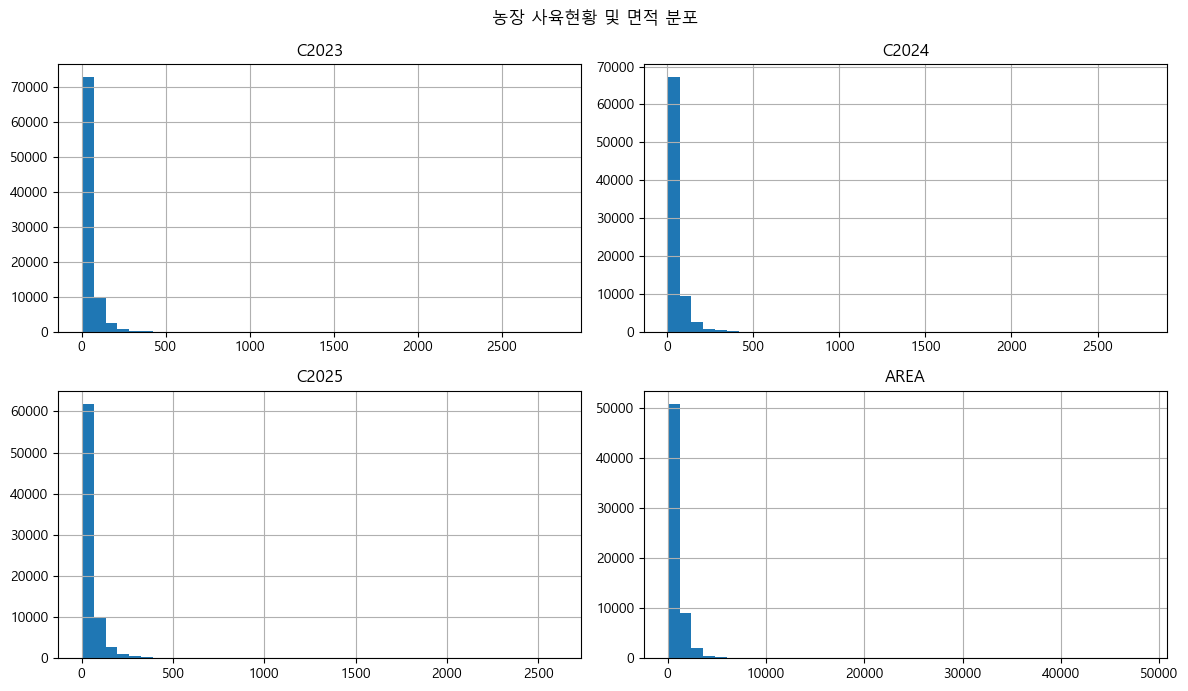

,count
DEAD_REASON,
NaN,234276
설사,8230
우결핵,4479
브루셀라 살처분,3456
설사병,3378
호흡기,3184
사고사,2594
폐렴,2300
구제역,2081


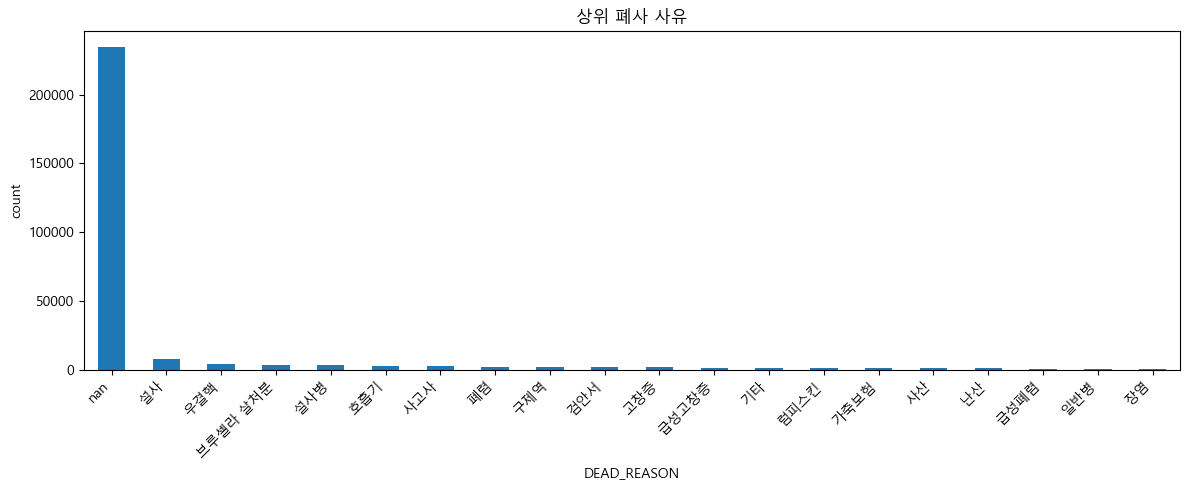

lineage sample shape: (200000, 8)
KPN_NO 고유값 수: 1468
FATHER_CATTLE_NO 고유값 수: 1010
MOTHER_ANIMAL_NO 고유값 수: 182919


In [ ]:
display(area.describe(include='all').T)

area_numeric = ['C2023', 'C2024', 'C2025', 'AREA']
area_numeric = [col for col in area_numeric if col in area.columns]
area[area_numeric].hist(figsize=(12, 7), bins=40)
plt.suptitle('농장 사육현황 및 면적 분포')
plt.tight_layout()
plt.show()

death_reason_counts = death['DEAD_REASON'].value_counts(dropna=False).head(20)
display(death_reason_counts.to_frame('count'))

plt.figure(figsize=(12, 5))
death_reason_counts.plot(kind='bar')
plt.title('상위 폐사 사유')
plt.xlabel('DEAD_REASON')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('lineage sample shape:', lineage_sample.shape)
for col in ['KPN_NO', 'FATHER_CATTLE_NO', 'MOTHER_ANIMAL_NO']:
    if col in lineage_sample.columns:
        print(col, '고유값 수:', lineage_sample[col].nunique(dropna=True))

## 11. 농장 변수 병합 후 EDA

,FARM_UNIQUE_NO,abatt_year,farm_count_year,AREA,farm_density,LAST_GRADE
0,hqh4Qmh5g+ymbYtqjAeKeA==,2023,7.0,95.00,0.073684,3B
1,N5qW6dZ91QWCMHg/1kPdlA==,2023,NaN,NaN,NaN,1B
2,5UbtU8TgV2yu3Y4/jxuNMQ==,2023,108.0,977.28,0.110511,1++B
3,5UbtU8TgV2yu3Y4/jxuNMQ==,2023,90.0,977.28,0.092092,1++B
4,N5qW6dZ91QWCMHg/1kPdlA==,2023,NaN,NaN,NaN,1++B


c:\Users\010hy\anaconda3\envs\py2\lib\site-packages\pandas\core\nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
farm_count_year,206769.0,133.216783,188.686795,1.000000,36.000000,82.000000,160.000000,2829.0
AREA,140443.0,1832.309673,2390.680490,0.000000,700.250000,1288.000000,2256.640000,38692.0
farm_density,136753.0,inf,NaN,0.000164,0.040476,0.067308,0.096025,inf


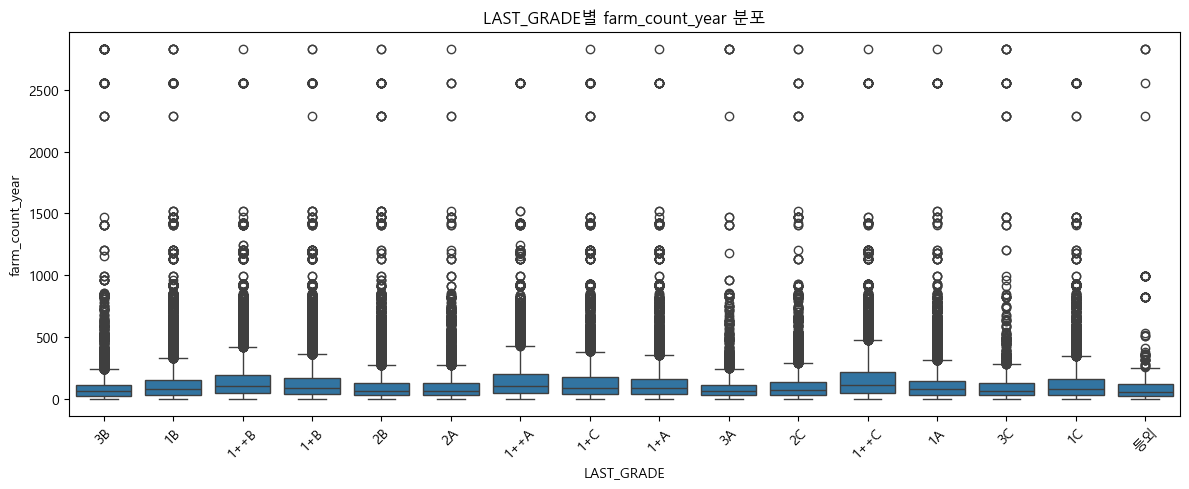

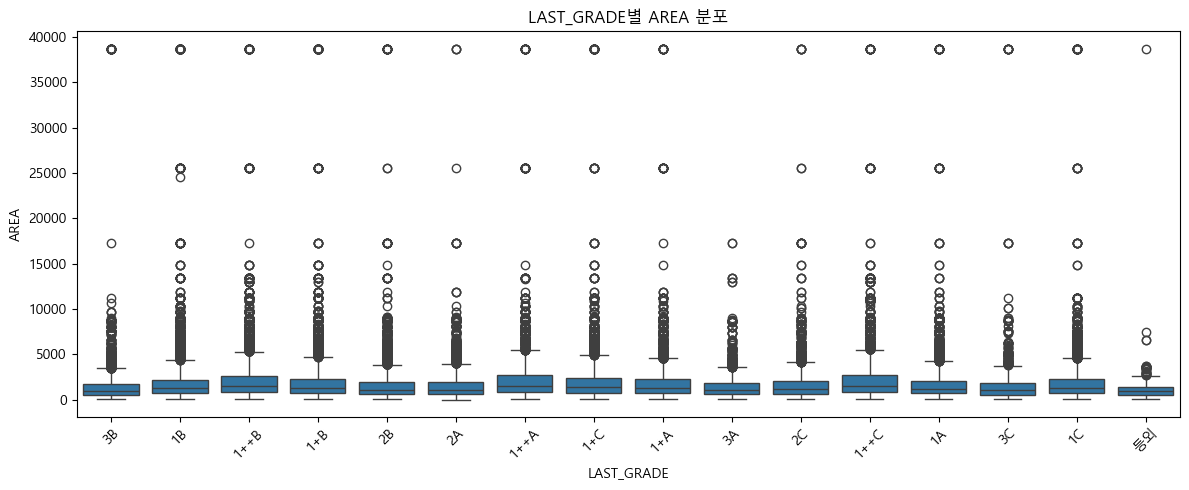

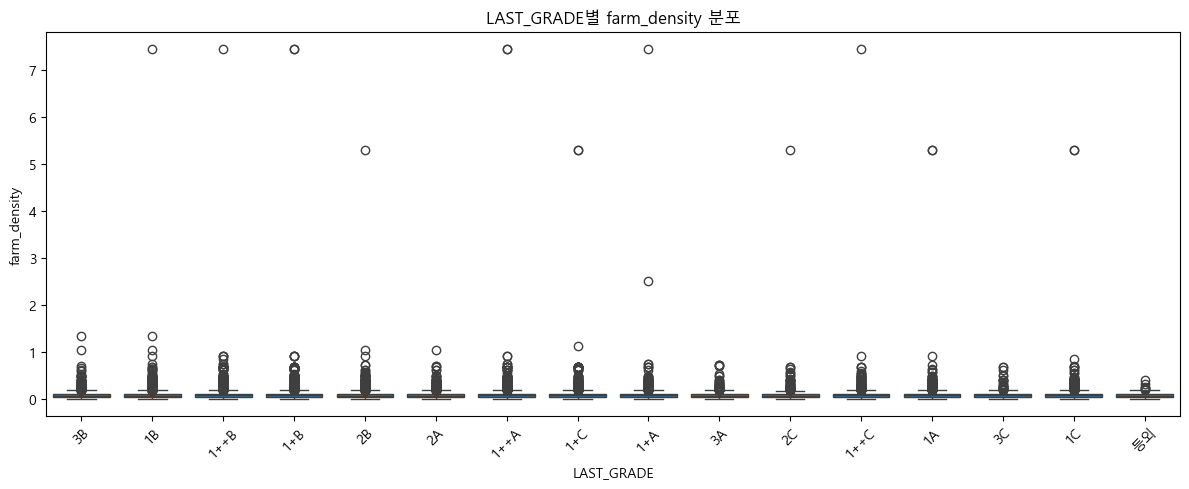

In [ ]:
train_area = train.merge(area, on='FARM_UNIQUE_NO', how='left')

def get_farm_count(row):
    if row['abatt_year'] == 2023:
        return row.get('C2023')
    if row['abatt_year'] == 2024:
        return row.get('C2024')
    if row['abatt_year'] == 2025:
        return row.get('C2025')
    return np.nan

train_area['farm_count_year'] = train_area.apply(get_farm_count, axis=1)
train_area['farm_density'] = train_area['farm_count_year'] / train_area['AREA']

display(train_area[['FARM_UNIQUE_NO', 'abatt_year', 'farm_count_year', 'AREA', 'farm_density', 'LAST_GRADE']].head())
display(train_area[['farm_count_year', 'AREA', 'farm_density']].describe().T)

for col in ['farm_count_year', 'AREA', 'farm_density']:
    plt.figure(figsize=(12, 5))
    if sns is not None:
        sns.boxplot(data=train_area, x='LAST_GRADE', y=col)
    else:
        train_area.boxplot(column=col, by='LAST_GRADE', rot=45)
    plt.title(f'LAST_GRADE별 {col} 분포')
    plt.xlabel('LAST_GRADE')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 12. 도축일 당일 기상 병합 후 EDA

첫 EDA에서는 간단하게 도축일 당일의 기상값을 붙여 봅니다. 모델링에서는 아래 13번처럼 도축 전 30/90/180일 요약 기상 변수를 쓰는 것이 더 좋습니다.

,stn,ABATT_DATE,LAST_GRADE,ta_max,ta_min,rn_day,rhm_avg,ws_davg
0,563,2023-01-01,3B,4.6,-5.9,0.0,39.0,5.3
1,560,2023-01-01,1B,2.5,-7.9,0.0,50.0,2.6
2,837,2023-01-01,1++B,6.7,-2.0,0.0,43.0,2.1
3,560,2023-01-01,1++B,2.5,-7.9,0.0,50.0,2.6
4,560,2023-01-01,1B,2.5,-7.9,0.0,50.0,2.6


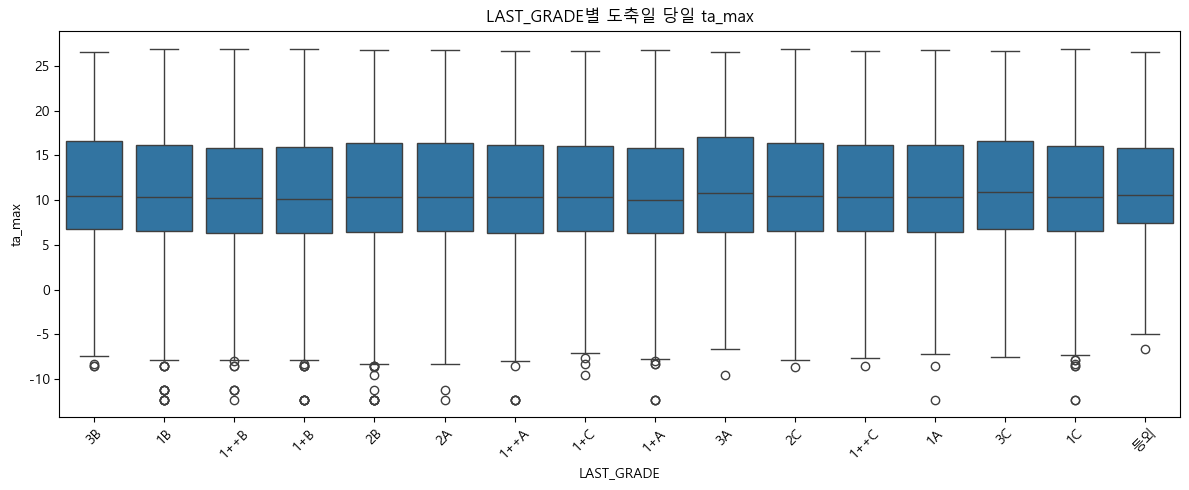

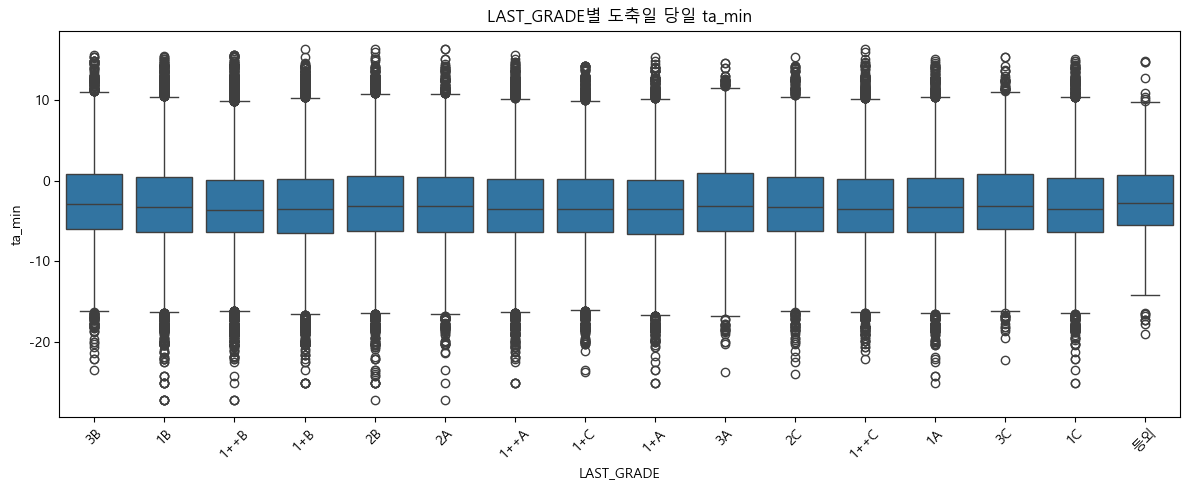

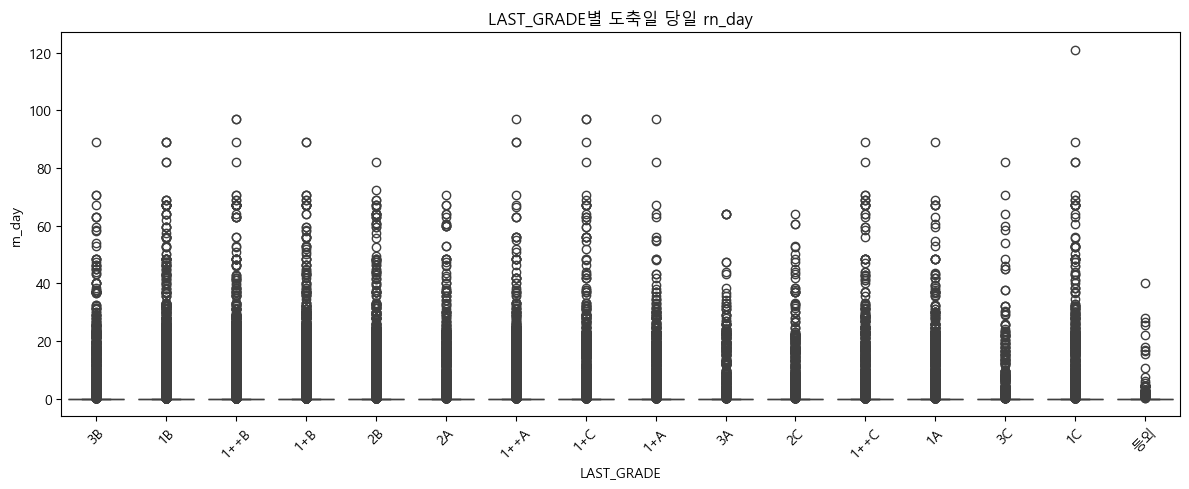

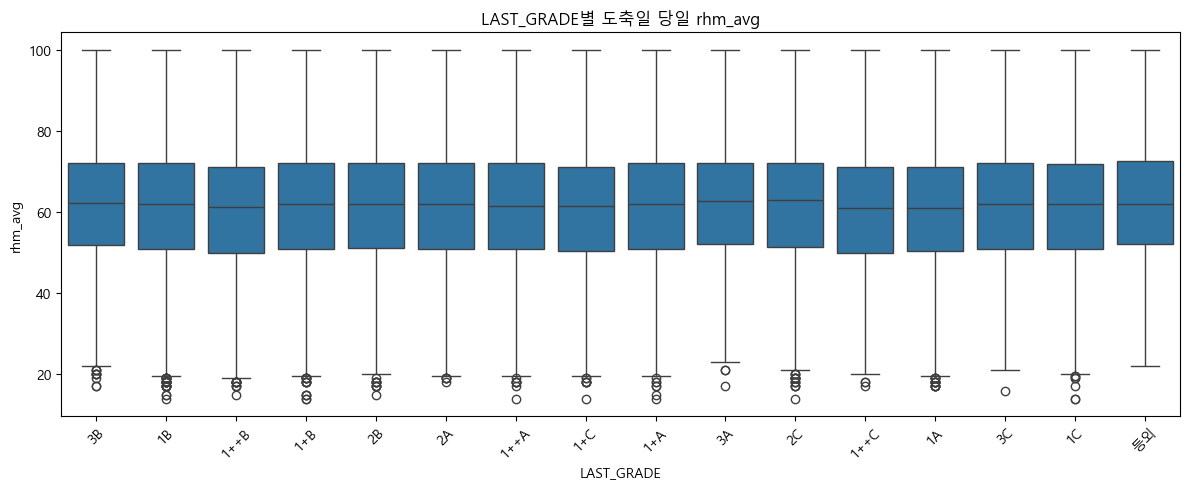

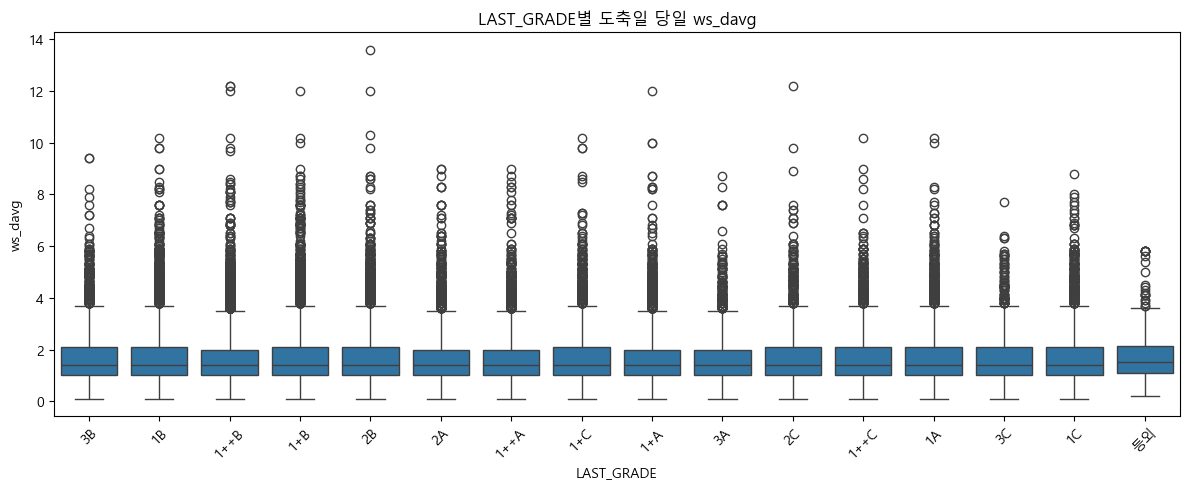

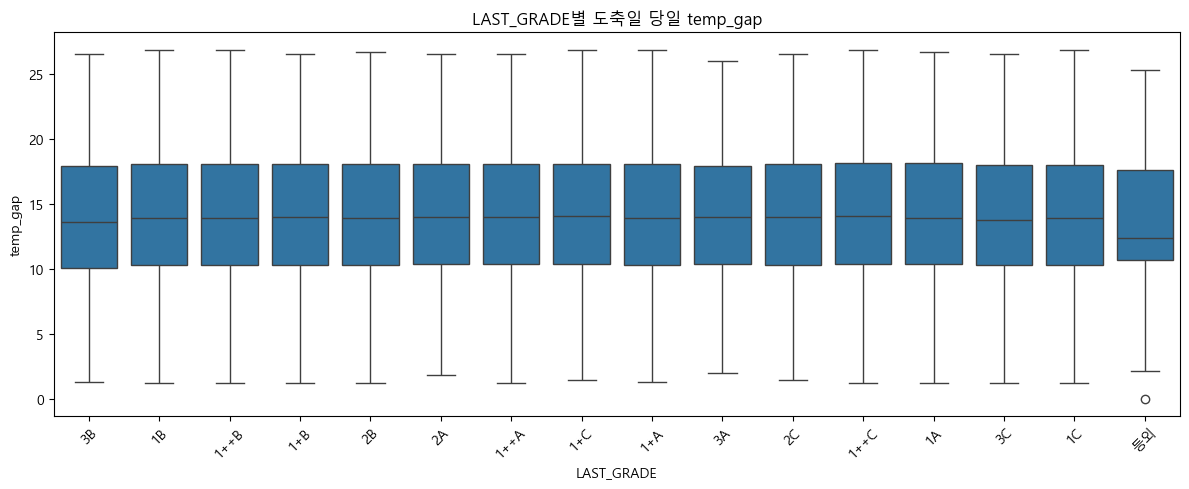

In [ ]:
weather_day = weather.rename(columns={'date': 'ABATT_DATE'})
train_weather_day = train.merge(weather_day, on=['stn', 'ABATT_DATE'], how='left')

display(train_weather_day[['stn', 'ABATT_DATE', 'LAST_GRADE', 'ta_max', 'ta_min', 'rn_day', 'rhm_avg', 'ws_davg']].head())

weather_grade_cols = ['ta_max', 'ta_min', 'rn_day', 'rhm_avg', 'ws_davg', 'temp_gap']
for col in weather_grade_cols:
    plt.figure(figsize=(12, 5))
    if sns is not None:
        sns.boxplot(data=train_weather_day, x='LAST_GRADE', y=col)
    else:
        train_weather_day.boxplot(column=col, by='LAST_GRADE', rot=45)
    plt.title(f'LAST_GRADE별 도축일 당일 {col}')
    plt.xlabel('LAST_GRADE')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 13. 도축 전 기상 시계열 요약 변수 생성

기상 데이터는 일별 시계열 데이터이므로, 도축일 기준 과거 30일/90일/180일 평균 또는 합계로 요약합니다. 여기서는 같은 관측소의 과거 날짜만 사용하기 위해 `shift(1)`을 적용하여 도축일 당일과 이후 정보가 들어가지 않게 했습니다.

In [ ]:
weather_roll = weather.sort_values(['stn', 'date']).copy()
windows = [30, 90, 180]

mean_cols = ['ta_max', 'ta_min', 'rhm_avg', 'ws_davg', 'temp_gap']
sum_cols = ['rn_day', 'hot_day', 'cold_day', 'rain_day', 'humid_day']

for w in windows:
    min_periods = max(7, w // 3)
    for col in mean_cols:
        weather_roll[f'{col}_mean_{w}d'] = (
            weather_roll.groupby('stn')[col]
            .transform(lambda s: s.shift(1).rolling(w, min_periods=min_periods).mean())
        )
    for col in sum_cols:
        weather_roll[f'{col}_sum_{w}d'] = (
            weather_roll.groupby('stn')[col]
            .transform(lambda s: s.shift(1).rolling(w, min_periods=min_periods).sum())
        )

weather_feature_cols = ['stn', 'date'] + [col for col in weather_roll.columns if col.endswith('d')]
weather_features = weather_roll[weather_feature_cols].rename(columns={'date': 'ABATT_DATE'})

train_weather = train.merge(weather_features, on=['stn', 'ABATT_DATE'], how='left')
print('train_weather shape:', train_weather.shape)
display(train_weather.head())

train_weather shape: (200000, 57)


,sido,sigungu,eupmyeondong,stn,ABATT_DATE,JUDGE_DATE,JUDGE_SEX,WEIGHT,BACKFAT,REA,WINDEX,WGRADE,INSFAT,YUKSAK,FATSAK,TISSUE,GROWTH,COST_AMT,AGE,BIRTH_YMD,CATTLE_NO,FARM_UNIQUE_NO,LAST_GRADE,abatt_year,abatt_month,judge_delay,abatt_season,ta_max_mean_30d,ta_min_mean_30d,rhm_avg_mean_30d,ws_davg_mean_30d,temp_gap_mean_30d,rn_day_sum_30d,hot_day_sum_30d,cold_day_sum_30d,rain_day_sum_30d,humid_day_sum_30d,ta_max_mean_90d,ta_min_mean_90d,rhm_avg_mean_90d,ws_davg_mean_90d,temp_gap_mean_90d,rn_day_sum_90d,hot_day_sum_90d,cold_day_sum_90d,rain_day_sum_90d,humid_day_sum_90d,ta_max_mean_180d,ta_min_mean_180d,rhm_avg_mean_180d,ws_davg_mean_180d,temp_gap_mean_180d,rn_day_sum_180d,hot_day_sum_180d,cold_day_sum_180d,rain_day_sum_180d,humid_day_sum_180d
0,강원특별자치도,정선군,북평면,563,2023-01-01,2023-01-02,암,218,3.0,44.0,63.23,A,1.0,6.0,7.0,5.0,9.0,NaN,76,2016-09-15,mI4i8G0BJ8kWD6gdm77RmTzyuIx6N2ZMaZ7wFXx3xb4=,hqh4Qmh5g+ymbYtqjAeKeA==,3B,2023,1,1,winter,1.030000,-9.746667,62.000000,2.810000,10.776667,6.0,0.0,16.0,3.0,2.0,10.973333,-1.052222,71.577778,2.077778,12.025556,154.5,0.0,16.0,16.0,33.0,18.938333,8.346111,77.927778,1.831667,10.592222,897.5,20.0,16.0,55.0,102.0
1,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,520,12.0,100.0,61.46,B,4.0,5.0,3.0,3.0,3.0,NaN,32,2020-05-04,tMgfi1p35taO9GH4XN4x0bfO8czy79B8V9NyczRuV+8=,N5qW6dZ91QWCMHg/1kPdlA==,1B,2023,1,1,winter,-0.476667,-12.876667,68.000000,2.166667,12.400000,5.5,0.0,20.0,3.0,6.0,9.903333,-3.782222,75.444444,1.711111,13.685556,171.5,0.0,22.0,18.0,40.0,17.996667,6.184444,81.705556,1.611111,11.812222,1046.5,15.0,22.0,56.0,122.0
2,경상북도,영주시,이산면,837,2023-01-01,2023-01-02,거세,452,14.0,104.0,61.86,B,9.0,4.0,3.0,1.0,3.0,NaN,29,2020-08-03,mdsSD4/sB06U68LNT6P/GUwei2ISyIBZ+R04iLw2mX0=,5UbtU8TgV2yu3Y4/jxuNMQ==,1++B,2023,1,1,winter,2.606667,-9.273333,65.933333,0.880000,11.880000,1.5,0.0,13.0,1.0,3.0,12.245556,-1.141111,73.277778,0.624444,13.386667,92.5,0.0,13.0,13.0,30.0,19.995556,8.614444,80.061111,0.491018,11.381111,681.0,24.0,13.0,51.0,110.0
3,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,454,12.0,95.0,61.83,B,9.0,5.0,3.0,1.0,3.0,NaN,32,2020-05-10,LZWd4YatUD851LyC/LFXuxPW7KEXTwVWQONOwqrkLPI=,N5qW6dZ91QWCMHg/1kPdlA==,1++B,2023,1,1,winter,-0.476667,-12.876667,68.000000,2.166667,12.400000,5.5,0.0,20.0,3.0,6.0,9.903333,-3.782222,75.444444,1.711111,13.685556,171.5,0.0,22.0,18.0,40.0,17.996667,6.184444,81.705556,1.611111,11.812222,1046.5,15.0,22.0,56.0,122.0
4,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,462,10.0,78.0,61.24,B,4.0,5.0,3.0,3.0,3.0,NaN,32,2020-05-11,A4FF/dhr8vg7JeW/eqc3922pA69nEaLL/+uoAusZqyU=,N5qW6dZ91QWCMHg/1kPdlA==,1B,2023,1,1,winter,-0.476667,-12.876667,68.000000,2.166667,12.400000,5.5,0.0,20.0,3.0,6.0,9.903333,-3.782222,75.444444,1.711111,13.685556,171.5,0.0,22.0,18.0,40.0,17.996667,6.184444,81.705556,1.611111,11.812222,1046.5,15.0,22.0,56.0,122.0


,ta_max_mean_30d,ta_max_mean_90d,ta_max_mean_180d,rhm_avg_mean_90d,rn_day_sum_90d,hot_day_sum_90d,cold_day_sum_90d,humid_day_sum_90d,temp_gap_mean_90d
LAST_GRADE,,,,,,,,,
1++A,7.664,9.075,15.966,66.968,80.049,0.0,12.245,17.322,12.368
1++B,7.598,9.054,15.998,66.825,80.595,0.0,12.073,16.960,12.289
1++C,7.777,9.232,16.147,66.469,79.663,0.0,11.251,16.365,12.324
1+A,7.506,8.840,15.788,67.198,80.301,0.0,12.864,17.675,12.310
1+B,7.613,8.954,15.883,67.159,80.645,0.0,12.293,17.473,12.279
1+C,7.734,9.114,16.025,66.960,81.152,0.0,11.557,17.156,12.293
1A,7.737,8.755,15.611,67.102,79.690,0.0,12.818,17.347,12.284
1B,7.747,8.929,15.803,67.222,80.973,0.0,12.061,17.531,12.261
1C,7.752,9.128,16.021,67.150,81.105,0.0,11.454,17.337,12.300


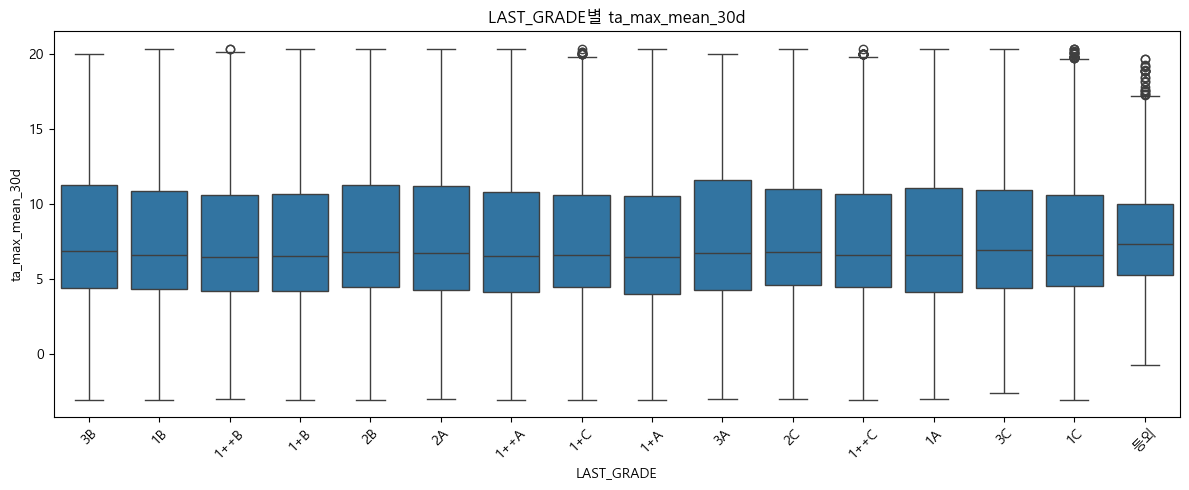

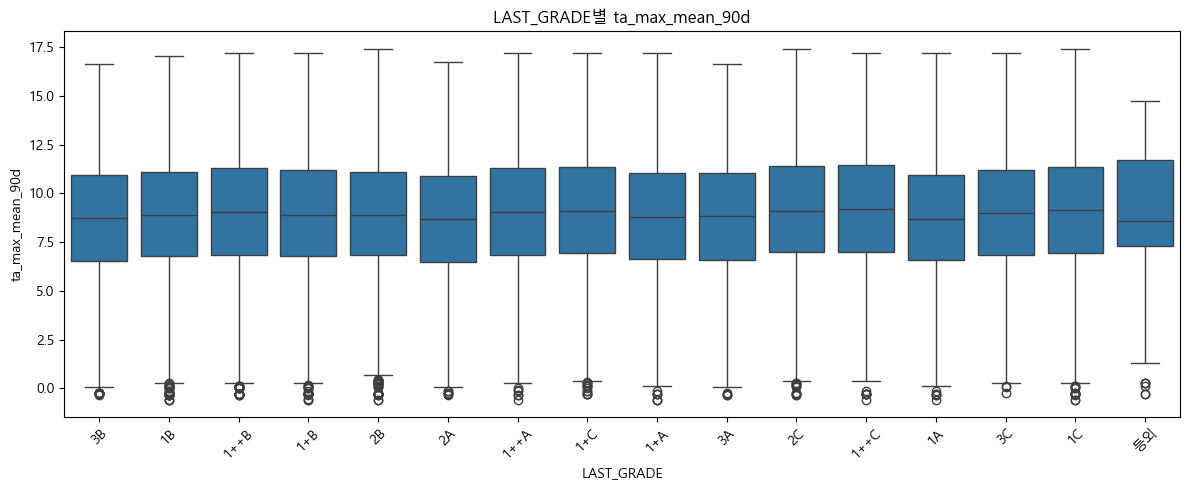

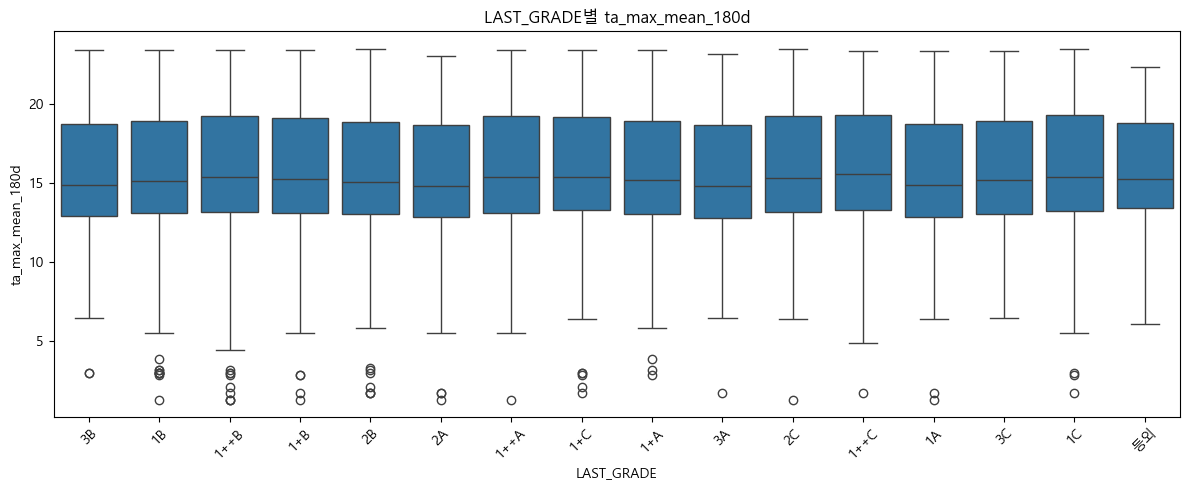

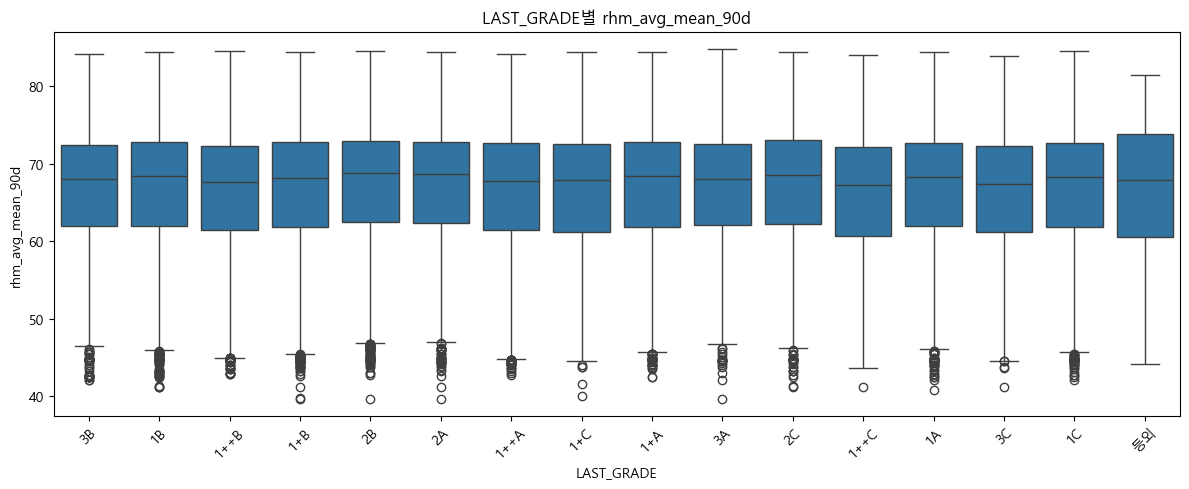

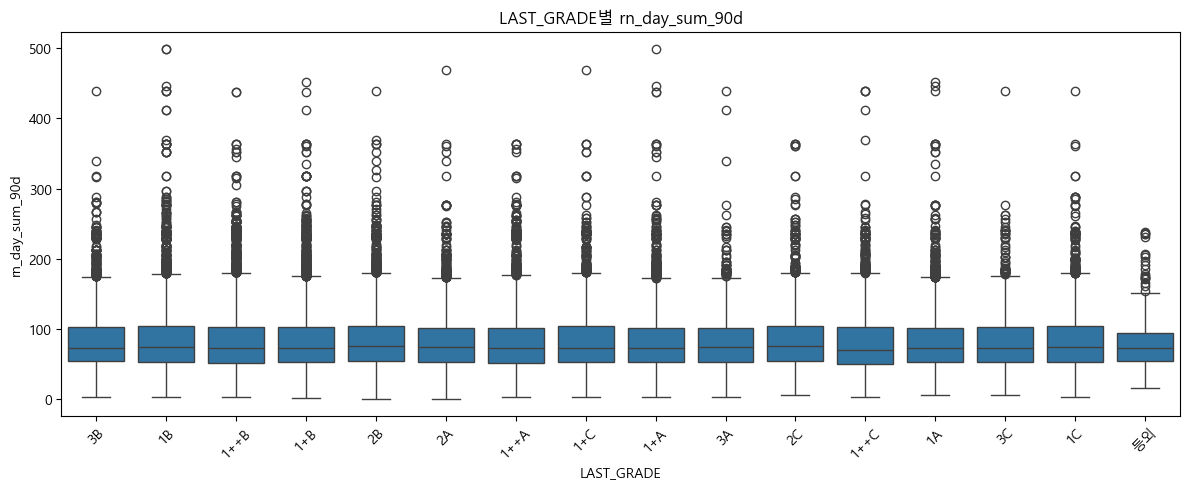

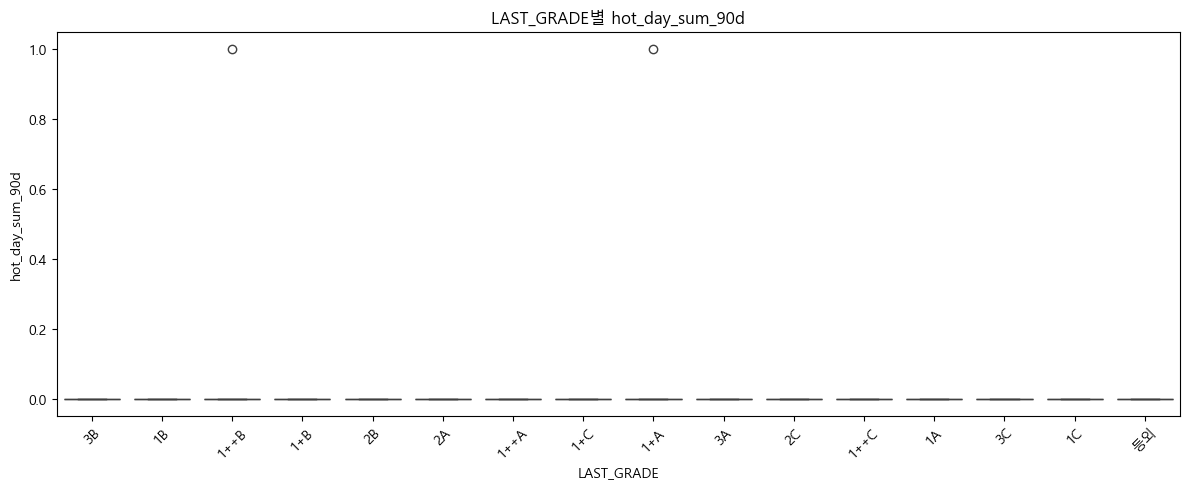

In [ ]:
selected_weather_features = [
    'ta_max_mean_30d', 'ta_max_mean_90d', 'ta_max_mean_180d',
    'rhm_avg_mean_90d', 'rn_day_sum_90d', 'hot_day_sum_90d',
    'cold_day_sum_90d', 'humid_day_sum_90d', 'temp_gap_mean_90d'
]
selected_weather_features = [col for col in selected_weather_features if col in train_weather.columns]

display(train_weather.groupby('LAST_GRADE')[selected_weather_features].mean().round(3))

for col in selected_weather_features[:6]:
    plt.figure(figsize=(12, 5))
    if sns is not None:
        sns.boxplot(data=train_weather, x='LAST_GRADE', y=col)
    else:
        train_weather.boxplot(column=col, by='LAST_GRADE', rot=45)
    plt.title(f'LAST_GRADE별 {col}')
    plt.xlabel('LAST_GRADE')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 14. 상관관계 확인

수치형 도체 변수, 농장 변수, 기상 요약 변수 간의 관계를 확인합니다.

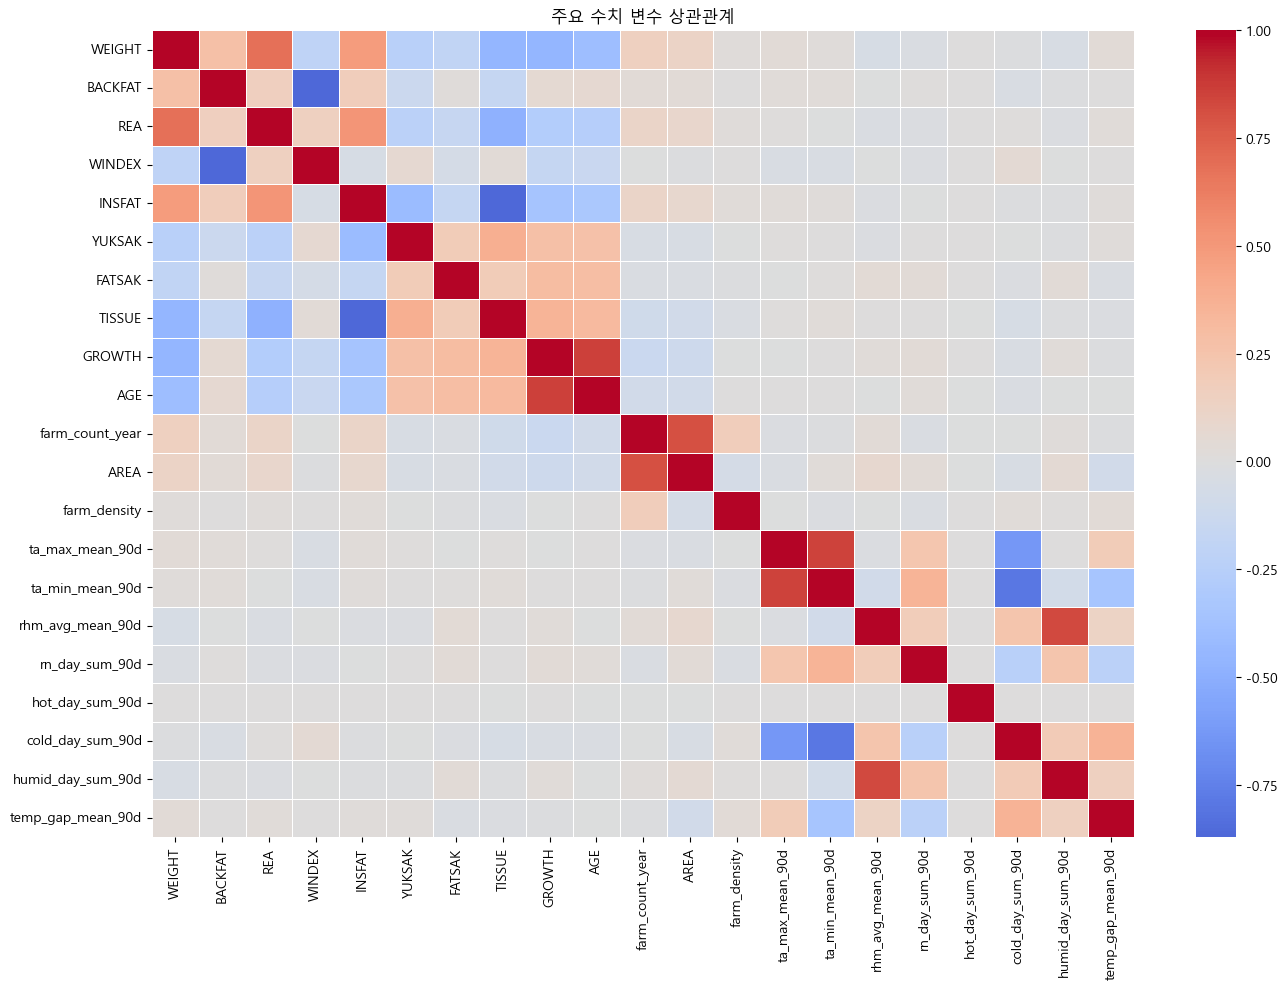

In [ ]:
eda_merged = train_weather.merge(
    train_area[['CATTLE_NO', 'farm_count_year', 'AREA', 'farm_density']],
    on='CATTLE_NO',
    how='left'
)

corr_cols = [
    'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'AGE',
    'farm_count_year', 'AREA', 'farm_density',
    'ta_max_mean_90d', 'ta_min_mean_90d', 'rhm_avg_mean_90d', 'rn_day_sum_90d',
    'hot_day_sum_90d', 'cold_day_sum_90d', 'humid_day_sum_90d', 'temp_gap_mean_90d'
]
corr_cols = [col for col in corr_cols if col in eda_merged.columns]
corr = eda_merged[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
if sns is not None:
    sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
else:
    plt.imshow(corr, cmap='coolwarm')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
plt.title('주요 수치 변수 상관관계')
plt.tight_layout()
plt.show()

## 15. EDA 결과 정리용 메모

아래 항목을 보고서에 정리하면 좋습니다.

- `LAST_GRADE` 클래스 불균형 여부
- 성별, 월령, 도체중, 근내지방도 등 기본 도체 특성과 등급의 관계
- 도축 월/계절별 등급 분포 차이
- 기상 변수 중 도축 전 30/90/180일 중 어떤 기간이 등급 차이를 더 잘 설명하는지
- 농장 면적, 사육두수, 사육밀도와 도체 성적의 관계
- 폐사 사유와 농장별 위험 지표 활용 가능성
- 혈통 변수는 범주 수가 많으므로 모델링 때 집계형 변수로 바꿀 필요가 있음

In [ ]:
# 필요하면 EDA용 병합 데이터를 저장합니다.
# 파일이 커질 수 있으므로 기본은 주석 처리했습니다.
# eda_merged.to_csv('hanwoo_eda_merged_sample.csv', index=False, encoding='utf-8-sig')